In [3]:
import sys

# Supprimer le chemin corrompu de la session
bad_path = r"C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages"
if bad_path in sys.path:
    sys.path.remove(bad_path)
    print("Chemin supprimé ✅")

# Vérifier quel matplotlib sera chargé
import importlib
spec = importlib.util.find_spec("matplotlib")
print("matplotlib chargé depuis :", spec.origin)

import matplotlib.pyplot as plt
print("matplotlib OK ✅")

matplotlib chargé depuis : C:\Users\Dell\anaconda3\envs\pfe\lib\site-packages\matplotlib\__init__.py


ImportError: cannot import name 'cbook' from partially initialized module 'matplotlib' (most likely due to a circular import) (C:\Users\Dell\anaconda3\envs\pfe\lib\site-packages\matplotlib\__init__.py)

In [1]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [151]:
filepath = r"C:\Users\Dell\Desktop\Rapport PFE\Nouveau dossier\FinalDataKomax.xlsx"

In [152]:
# ============================================================= 
# Lire SANS header pour voir toute la structure brute
# pour savoir les lignes de header
# =============================================================

DataKomax_raw = pd.read_excel(filepath, header=None, engine='openpyxl')

print("Shape brut:", DataKomax_raw.shape)
print("\n--- 20 premières lignes ---")
for i in range(min(20, len(DataKomax_raw))):
    row = DataKomax_raw.iloc[i].tolist()
    # Afficher seulement les valeurs non-NaN
    non_nan = [(j, v) for j, v in enumerate(row) if pd.notna(v)]
    if non_nan:
        print(f"Ligne {i}: {non_nan}")

Shape brut: (25697, 24)

--- 20 premières lignes ---
Ligne 2: [(7, 'Down Time  Viewer Report -Komax Machine\nOnly maintenance Stops\n ')]
Ligne 9: [(1, 'Machine'), (2, 'Type Of Failure'), (6, 'Defect Code'), (8, 'Microstop Description'), (9, 'Type'), (10, 'Declaration Start Time'), (13, 'Call Maintenance Time'), (15, 'Intervention Start Time'), (16, 'Declaration End Time'), (17, 'Down Time'), (18, 'Delay Time'), (19, 'Operator ID'), (20, 'Maintenance ID'), (21, 'Comment'), (22, 'Serial Device'), (23, 'Date')]
Ligne 10: [(1, 'KOMAX_38'), (2, 'KIT-JOINT'), (6, 'SAP05'), (8, 'P-B11/S11'), (9, 'Maintenance'), (10, datetime.datetime(2025, 4, 1, 22, 10, 55)), (13, datetime.datetime(2025, 4, 1, 22, 11, 2)), (15, datetime.datetime(2025, 4, 1, 22, 18, 2)), (16, datetime.datetime(2025, 4, 1, 22, 18, 44, 80000)), (17, '00:07:42'), (18, '00:07:00'), (19, '92473'), (20, '5683'), (21, 'nett capteur B11'), (22, '30691'), (23, datetime.datetime(2025, 4, 1, 0, 0))]
Ligne 11: [(1, 'KOMAX_5'), (2, 'MARQU

In [153]:
# ======================================================
# Header à la ligne 9, données à partir de la ligne 10
# =======================================================

DataKomax = pd.read_excel(filepath, header=9, engine='openpyxl')

print("Shape brut:", DataKomax.shape)
print("Colonnes:", DataKomax.columns.tolist())

Shape brut: (25687, 24)
Colonnes: ['Unnamed: 0', 'Machine', 'Type Of Failure', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Defect Code', 'Unnamed: 7', 'Microstop Description', 'Type', 'Declaration Start Time', 'Unnamed: 11', 'Unnamed: 12', 'Call Maintenance Time', 'Unnamed: 14', 'Intervention Start Time', 'Declaration End Time', 'Down Time', 'Delay Time', 'Operator ID', 'Maintenance ID', 'Comment', 'Serial Device', 'Date']


In [154]:
# ================================================================
# Supprimer toutes les colonnes Unnamed (colonnes vides sans nom)
# ================================================================

DataKomax = DataKomax.loc[:, ~DataKomax.columns.astype(str).str.startswith('Unnamed')]

print("Colonnes après nettoyage:", DataKomax.columns.tolist())
print("Shape:", DataKomax.shape)

Colonnes après nettoyage: ['Machine', 'Type Of Failure', 'Defect Code', 'Microstop Description', 'Type', 'Declaration Start Time', 'Call Maintenance Time', 'Intervention Start Time', 'Declaration End Time', 'Down Time', 'Delay Time', 'Operator ID', 'Maintenance ID', 'Comment', 'Serial Device', 'Date']
Shape: (25687, 16)


In [155]:
# ====================================
# Nettoyer les noms de colonnes
# ====================================

DataKomax.columns = (DataKomax.columns
                     .str.strip()
                     .str.replace('\n', ' ')
                     .str.replace('\r', '')
                     .str.replace('  ', ' '))


print(DataKomax.columns.tolist())

['Machine', 'Type Of Failure', 'Defect Code', 'Microstop Description', 'Type', 'Declaration Start Time', 'Call Maintenance Time', 'Intervention Start Time', 'Declaration End Time', 'Down Time', 'Delay Time', 'Operator ID', 'Maintenance ID', 'Comment', 'Serial Device', 'Date']


In [156]:
# ================================================
# Supprimer les lignes vides
# ================================================

DataKomax = DataKomax.dropna(how='all').reset_index(drop=True)
print("Shape après suppression lignes vides:", DataKomax.shape)

Shape après suppression lignes vides: (25687, 16)


In [157]:
# ==========================================================
# Afficher les colonnes EXACTES avec leurs caractères cachés
# =========================================================

for col in DataKomax.columns:
    print(repr(col))

'Machine'
'Type Of Failure'
'Defect Code'
'Microstop Description'
'Type'
'Declaration Start Time'
'Call Maintenance Time'
'Intervention Start Time'
'Declaration End Time'
'Down Time'
'Delay Time'
'Operator ID'
'Maintenance ID'
'Comment'
'Serial Device'
'Date'


In [160]:
# ======================================
# Vérifier les colonnes disponibles
# ======================================

print("Colonnes disponibles:")
print(DataKomax.columns.tolist())

Colonnes disponibles:
['Machine', 'Type Of Failure', 'Defect Code', 'Microstop Description', 'Type', 'Declaration Start Time', 'Call Maintenance Time', 'Intervention Start Time', 'Declaration End Time', 'Down Time', 'Delay Time', 'Operator ID', 'Maintenance ID', 'Comment', 'Serial Device', 'Date']


In [161]:
# ========================================================
# Voir les valeurs brutes de Down Time et Delay Time
# ========================================================

print("\n--- Down Time brut ---")
print(DataKomax['Down Time'].head(10).tolist())
print("Type:", DataKomax['Down Time'].dtype)

print("\n--- Delay Time brut ---")
print(DataKomax['Delay Time'].head(10).tolist())
print("Type:", DataKomax['Delay Time'].dtype)


--- Down Time brut ---
['00:07:42', '00:09:41', '00:11:43', '00:49:22', '00:16:27', '00:31:30', '00:05:52', '00:04:27', '00:03:39', '00:11:35']
Type: object

--- Delay Time brut ---
['00:07:00', '00:03:33', '00:03:49', '00:04:41', '00:10:46', '00:23:12', '00:00:06', '00:01:45', '00:02:38', '00:09:47']
Type: object


In [162]:
# Conversion STRING → minutes SANS supprimer les originales
def to_minutes_str(t):
    try:
        p = str(t).split(':')
        return round(int(p[0]) * 60 + int(p[1]) + int(p[2]) / 60, 2)
    except:
        return np.nan

# Ajouter les nouvelles colonnes en gardant les originales
DataKomax['Down Time (min)']  = DataKomax['Down Time'].apply(to_minutes_str)
DataKomax['Delay Time (min)'] = DataKomax['Delay Time'].apply(to_minutes_str)

# Vérification
print(DataKomax[['Machine', 'Down Time', 'Down Time (min)', 
                 'Delay Time', 'Delay Time (min)']].head(10))

print(f"\nShape: {DataKomax.shape}")
print(f"Colonnes: {DataKomax.columns.tolist()}")
print(DataKomax[['Machine', 'Type Of Failure', 'Down Time (min)', 'Down Time', 'Delay Time (min)', 'Delay Time']].head(10))

    Machine Down Time  Down Time (min) Delay Time  Delay Time (min)
0  KOMAX_38  00:07:42             7.70   00:07:00              7.00
1   KOMAX_5  00:09:41             9.68   00:03:33              3.55
2  KOMAX_46  00:11:43            11.72   00:03:49              3.82
3  KOMAX_24  00:49:22            49.37   00:04:41              4.68
4  KOMAX_17  00:16:27            16.45   00:10:46             10.77
5  KOMAX_43  00:31:30            31.50   00:23:12             23.20
6  KOMAX_10  00:05:52             5.87   00:00:06              0.10
7  KOMAX_18  00:04:27             4.45   00:01:45              1.75
8   KOMAX_4  00:03:39             3.65   00:02:38              2.63
9  KOMAX_16  00:11:35            11.58   00:09:47              9.78

Shape: (25687, 18)
Colonnes: ['Machine', 'Type Of Failure', 'Defect Code', 'Microstop Description', 'Type', 'Declaration Start Time', 'Call Maintenance Time', 'Intervention Start Time', 'Declaration End Time', 'Down Time', 'Delay Time', 'Operator ID',

In [163]:
# Convertir toutes les colonnes datetime
for col in ['Declaration Start Time', 'Call Maintenance Time', 
            'Intervention Start Time', 'Declaration End Time']:
    DataKomax[col] = pd.to_datetime(DataKomax[col], errors='coerce')

In [164]:
# ================================================
# CALCUL DES 4 DÉLAIS MAINTENANCE (en minutes)
# ================================================

# 1. Temps de réaction : détection → appel maintenance
DataKomax['Reaction Time (min)'] = (
    (DataKomax['Call Maintenance Time'] - DataKomax['Declaration Start Time'])
    .dt.total_seconds() / 60).round(2)

# 2. Temps d'attente : appel → arrivée technicien
DataKomax['Waiting Time (min)'] = (
    (DataKomax['Intervention Start Time'] - DataKomax['Call Maintenance Time'])
    .dt.total_seconds() / 60).round(2)

# 3. Temps d'intervention : arrivée technicien → fin panne
DataKomax['Intervention Time (min)'] = (
    (DataKomax['Declaration End Time'] - DataKomax['Intervention Start Time'])
    .dt.total_seconds() / 60).round(2)

# 4. Temps total panne : détection → fin (= Down Time total)
DataKomax['Total Maintenance Time (min)'] = (
    (DataKomax['Declaration End Time'] - DataKomax['Call Maintenance Time'])
    .dt.total_seconds() / 60).round(2)

In [165]:
# ================================================
# VÉRIFICATION
# ================================================

cols_check = ['Machine', 'Type Of Failure',
              'Reaction Time (min)', 'Waiting Time (min)', 
              'Intervention Time (min)', 'Total Maintenance Time (min)']

print(DataKomax[cols_check].head(10))
print(f"\nShape: {DataKomax.shape}")

print("\n=== Statistiques des délais ===")
for col in ['Reaction Time (min)', 'Waiting Time (min)', 
            'Intervention Time (min)', 'Total Maintenance Time (min)']:
    print(f"\n{col}:")
    print(DataKomax[col].describe().round(2))

    Machine     Type Of Failure  Reaction Time (min)  Waiting Time (min)  \
0  KOMAX_38           KIT-JOINT                 0.12                7.00   
1   KOMAX_5            MARQUAGE                 0.10                3.55   
2  KOMAX_46    MINI-APPLICATEUR                 1.30                3.82   
3  KOMAX_24    MINI-APPLICATEUR                 0.10                4.68   
4  KOMAX_17    MINI-APPLICATEUR                 0.05               10.77   
5  KOMAX_43    MINI-APPLICATEUR                 0.03               23.20   
6  KOMAX_10    MINI-APPLICATEUR                 4.62                0.10   
7  KOMAX_18    MINI-APPLICATEUR                 0.32                1.75   
8   KOMAX_4  IT (Soft/Hardware)                 0.15                2.63   
9  KOMAX_16    MINI-APPLICATEUR                 0.03                9.78   

   Intervention Time (min)  Total Maintenance Time (min)  
0                     0.70                          7.70  
1                     6.14                   

In [166]:
# ====================================================
# Supprimer les délais négatifs (erreurs de saisie)
# Filtrer les valeurs aberrantes
# ====================================================

mask = (DataKomax['Reaction Time (min)']     >= 0) & \
       (DataKomax['Waiting Time (min)']       >= 0) & \
       (DataKomax['Intervention Time (min)']  >= 0) & \
       (DataKomax['Total Maintenance Time (min)'] > 0)

DataKomax_clean = DataKomax[mask].reset_index(drop=True)
print(f"Lignes supprimées (valeurs aberrantes): {len(DataKomax) - len(DataKomax_clean)}")
print(f"Shape final: {DataKomax_clean.shape}")

Lignes supprimées (valeurs aberrantes): 2
Shape final: (25685, 22)


In [167]:
# ======================================================================================================================================================
# VÉRIFICATION DES DONNÉES
# ======================================================================================================================================================

In [168]:
print("=== Aperçu ===")
print(DataKomax.head(3))

print("\n=== Types de colonnes ===")
print(DataKomax.dtypes)

print("\n=== Valeurs manquantes ===")
missing = DataKomax.isnull().sum()
print(missing[missing > 0])

print("\n=== Statistiques Down Time (min) ===")
print(DataKomax['Down Time'].describe())

=== Aperçu ===
    Machine   Type Of Failure Defect Code   Microstop Description  \
0  KOMAX_38         KIT-JOINT       SAP05               P-B11/S11   
1   KOMAX_5          MARQUAGE        MR05    P-Marquage illisible   
2  KOMAX_46  MINI-APPLICATEUR       MAP05  P-Pincement fil /Joint   

          Type Declaration Start Time Call Maintenance Time  \
0  Maintenance    2025-04-01 22:10:55   2025-04-01 22:11:02   
1  Maintenance    2025-04-01 22:21:29   2025-04-01 22:21:35   
2  Maintenance    2025-04-01 22:33:19   2025-04-01 22:34:37   

  Intervention Start Time    Declaration End Time Down Time  ...  \
0     2025-04-01 22:18:02 2025-04-01 22:18:44.080  00:07:42  ...   
1     2025-04-01 22:25:08 2025-04-01 22:31:16.670  00:09:41  ...   
2     2025-04-01 22:38:26 2025-04-01 22:46:20.377  00:11:43  ...   

  Maintenance ID                   Comment Serial Device       Date  \
0           5683          nett capteur B11         30691 2025-04-01   
1            404              rincage bu

In [169]:
if "Date" in DataKomax.columns:
    DataKomax = DataKomax.drop(columns=["Date"])

In [170]:
print(DataKomax.shape)

(25687, 21)


In [171]:
print(DataKomax.columns.tolist())

['Machine', 'Type Of Failure', 'Defect Code', 'Microstop Description', 'Type', 'Declaration Start Time', 'Call Maintenance Time', 'Intervention Start Time', 'Declaration End Time', 'Down Time', 'Delay Time', 'Operator ID', 'Maintenance ID', 'Comment', 'Serial Device', 'Down Time (min)', 'Delay Time (min)', 'Reaction Time (min)', 'Waiting Time (min)', 'Intervention Time (min)', 'Total Maintenance Time (min)']


In [172]:
DataKomax.head()

,Machine,Type Of Failure,Defect Code,Microstop Description,Type,Declaration Start Time,Call Maintenance Time,Intervention Start Time,Declaration End Time,Down Time,...,Operator ID,Maintenance ID,Comment,Serial Device,Down Time (min),Delay Time (min),Reaction Time (min),Waiting Time (min),Intervention Time (min),Total Maintenance Time (min)
0,KOMAX_38,KIT-JOINT,SAP05,P-B11/S11,Maintenance,2025-04-01 22:10:55,2025-04-01 22:11:02,2025-04-01 22:18:02,2025-04-01 22:18:44.080,00:07:42,...,92473,5683,nett capteur B11,30691,7.70,7.00,0.12,7.00,0.70,7.70
1,KOMAX_5,MARQUAGE,MR05,P-Marquage illisible,Maintenance,2025-04-01 22:21:29,2025-04-01 22:21:35,2025-04-01 22:25:08,2025-04-01 22:31:16.670,00:09:41,...,21262,404,rincage buse,54236,9.68,3.55,0.10,3.55,6.14,9.69
2,KOMAX_46,MINI-APPLICATEUR,MAP05,P-Pincement fil /Joint,Maintenance,2025-04-01 22:33:19,2025-04-01 22:34:37,2025-04-01 22:38:26,2025-04-01 22:46:20.377,00:11:43,...,28863,5833,reg position + reg tige,LS64215,11.72,3.82,1.30,3.82,7.91,11.72
3,KOMAX_24,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 22:53:15,2025-04-01 22:53:21,2025-04-01 22:58:02,2025-04-01 23:42:43.813,00:49:22,...,18797,5833,reg b moth,LS108783,49.37,4.68,0.10,4.68,44.70,49.38
4,KOMAX_17,MINI-APPLICATEUR,MAP02,P-Déformation connexion,Maintenance,2025-04-01 23:00:24,2025-04-01 23:00:27,2025-04-01 23:11:13,2025-04-01 23:16:54.623,00:16:27,...,25290,6032,centrag ecx+rg bellm,ls35745,16.45,10.77,0.05,10.77,5.69,16.46


In [173]:
DataKomax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25687 entries, 0 to 25686
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Machine                       25686 non-null  object        
 1   Type Of Failure               25686 non-null  object        
 2   Defect Code                   25686 non-null  object        
 3   Microstop Description         25686 non-null  object        
 4   Type                          25686 non-null  object        
 5   Declaration Start Time        25686 non-null  datetime64[ns]
 6   Call Maintenance Time         25686 non-null  datetime64[ns]
 7   Intervention Start Time       25686 non-null  datetime64[ns]
 8   Declaration End Time          25686 non-null  datetime64[ns]
 9   Down Time                     25687 non-null  object        
 10  Delay Time                    25687 non-null  object        
 11  Operator ID                 

In [174]:
DataKomax.describe(include="all")

,Machine,Type Of Failure,Defect Code,Microstop Description,Type,Declaration Start Time,Call Maintenance Time,Intervention Start Time,Declaration End Time,Down Time,...,Operator ID,Maintenance ID,Comment,Serial Device,Down Time (min),Delay Time (min),Reaction Time (min),Waiting Time (min),Intervention Time (min),Total Maintenance Time (min)
count,25686,25686,25686,25686,25686,25686,25686,25686,25686,25687,...,25682,25686,24283,18746,25687.000000,25687.000000,25686.000000,25686.000000,25686.000000,25686.000000
unique,63,20,195,188,1,NaN,NaN,NaN,NaN,2814,...,237,29,9639,3018,NaN,NaN,NaN,NaN,NaN,NaN
top,KOMAX_50,MINI-APPLICATEUR,MAP01,P-Avancement/Centrage,Maintenance,NaN,NaN,NaN,NaN,00:05:47,...,0000,5765,reglage bell mouth+essai,na,NaN,NaN,NaN,NaN,NaN,NaN
freq,828,10789,4350,4350,25686,NaN,NaN,NaN,NaN,50,...,1180,2252,587,1815,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2025-09-21 00:00:15.142801664,2025-09-21 01:13:42.370396160,2025-09-21 01:18:29.230631680,2025-09-21 01:28:21.367237120,NaN,...,NaN,NaN,NaN,NaN,29.338196,9.561624,73.453807,4.780992,9.868929,14.649938
min,NaN,NaN,NaN,NaN,NaN,2025-04-01 22:10:55,2025-04-01 22:11:02,2025-04-01 22:18:02,2025-04-01 22:18:44.080000,NaN,...,NaN,NaN,NaN,NaN,0.070000,0.000000,0.020000,0.000000,-25.510000,-22.570000
25%,NaN,NaN,NaN,NaN,NaN,2025-06-12 16:11:57,2025-06-12 16:11:59,2025-06-12 16:13:47.500000,2025-06-12 16:32:39.401999872,NaN,...,NaN,NaN,NaN,NaN,6.800000,1.975000,0.070000,1.972500,2.930000,6.800000
50%,NaN,NaN,NaN,NaN,NaN,2025-09-25 14:21:17,2025-09-25 14:25:34,2025-09-25 14:31:14.500000,2025-09-25 14:44:27.055000064,NaN,...,NaN,NaN,NaN,NaN,10.230000,3.620000,0.100000,3.620000,5.240000,10.240000
75%,NaN,NaN,NaN,NaN,NaN,2025-12-15 18:18:17.500000,2025-12-15 18:18:30.750000128,2025-12-15 18:24:46,2025-12-15 18:40:41.989500160,NaN,...,NaN,NaN,NaN,NaN,15.310000,6.280000,0.380000,6.280000,9.310000,15.320000
max,NaN,NaN,NaN,NaN,NaN,2026-03-31 23:51:24,2026-03-31 23:51:28,2026-03-31 23:59:48,2026-04-01 00:07:19.647000,NaN,...,NaN,NaN,NaN,NaN,376085.020000,122804.870000,14692.050000,217.080000,417.700000,527.530000


In [175]:
nb_doublons = (DataKomax.duplicated().sum())
print(f"Nombre de lignes dupliquées : {nb_doublons}")

Nombre de lignes dupliquées : 0


In [176]:
DataKomax.isna().sum()

Machine                            1
Type Of Failure                    1
Defect Code                        1
Microstop Description              1
Type                               1
Declaration Start Time             1
Call Maintenance Time              1
Intervention Start Time            1
Declaration End Time               1
Down Time                          0
Delay Time                         0
Operator ID                        5
Maintenance ID                     1
Comment                         1404
Serial Device                   6941
Down Time (min)                    0
Delay Time (min)                   0
Reaction Time (min)                1
Waiting Time (min)                 1
Intervention Time (min)            1
Total Maintenance Time (min)       1
dtype: int64

In [177]:
DataKomax.isna().mean() * 100

Machine                          0.003893
Type Of Failure                  0.003893
Defect Code                      0.003893
Microstop Description            0.003893
Type                             0.003893
Declaration Start Time           0.003893
Call Maintenance Time            0.003893
Intervention Start Time          0.003893
Declaration End Time             0.003893
Down Time                        0.000000
Delay Time                       0.000000
Operator ID                      0.019465
Maintenance ID                   0.003893
Comment                          5.465800
Serial Device                   27.021451
Down Time (min)                  0.000000
Delay Time (min)                 0.000000
Reaction Time (min)              0.003893
Waiting Time (min)               0.003893
Intervention Time (min)          0.003893
Total Maintenance Time (min)     0.003893
dtype: float64

In [178]:
# Identifier les valeurs manquantes
print("VALEURS MANQUANTES:")
missing = DataKomax.isnull().sum()
missing_pct = (missing / len(DataKomax)) * 100
missing_DataKomax = pd.DataFrame({
    'Colonne': missing.index,
    'Manquants': missing.values,
    'Pourcentage': missing_pct.values
})
missing_DataKomax = missing_DataKomax[missing_DataKomax['Manquants'] > 0].sort_values('Manquants', ascending=False)
display(missing_DataKomax)

VALEURS MANQUANTES:


,Colonne,Manquants,Pourcentage
14,Serial Device,6941,27.021451
13,Comment,1404,5.465800
11,Operator ID,5,0.019465
0,Machine,1,0.003893
19,Intervention Time (min),1,0.003893
18,Waiting Time (min),1,0.003893
17,Reaction Time (min),1,0.003893
12,Maintenance ID,1,0.003893
8,Declaration End Time,1,0.003893
1,Type Of Failure,1,0.003893


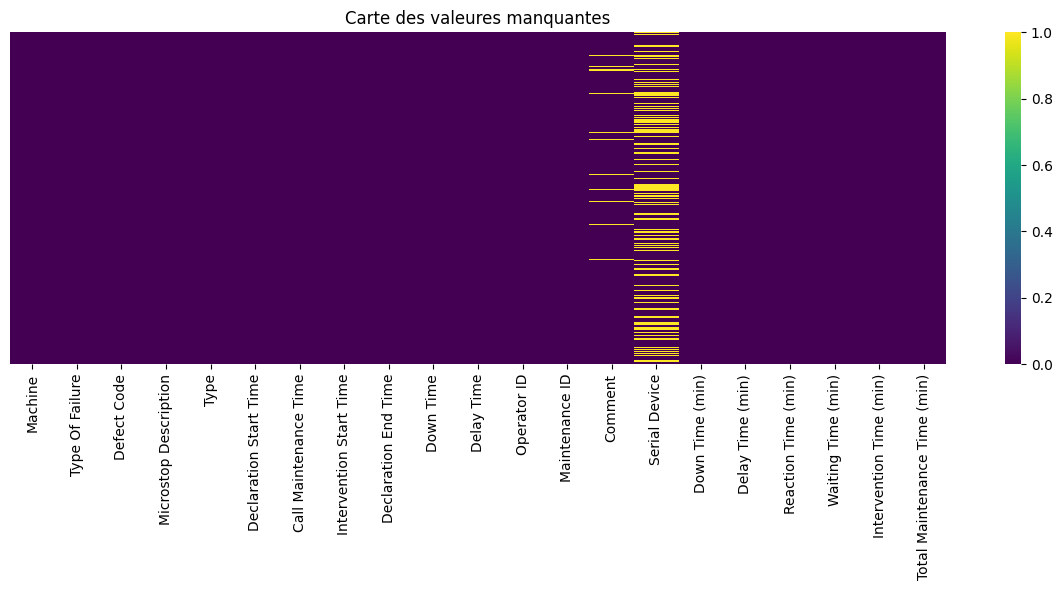

In [179]:
plt.figure(figsize=(12, 6))
sns.heatmap(DataKomax.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Carte des valeures manquantes')
plt.tight_layout()
plt.savefig('valeurs_manquantes.png')
plt.show()

In [180]:
# =====================================
# Traitement des valeurs manquantes
# ====================================

# 1. Comment → remplir par 'AUCUN COMMENTAIRE' (c'est du texte, pas critique pour ML)
DataKomax['Comment'] = DataKomax['Comment'].fillna('AUCUN COMMENTAIRE')

# 2. Serial Device → remplir par 'INCONNU'
DataKomax['Serial Device'] = DataKomax['Serial Device'].fillna('INCONNU')

# Vérification finale

print("=== Vérification après traitement ===")
print(DataKomax.isnull().sum())
print(f"\nPlus aucun NaN : {DataKomax.isnull().sum().sum() == 0} ✓")
print(f"Shape finale   : {DataKomax.shape}")

=== Vérification après traitement ===
Machine                         1
Type Of Failure                 1
Defect Code                     1
Microstop Description           1
Type                            1
Declaration Start Time          1
Call Maintenance Time           1
Intervention Start Time         1
Declaration End Time            1
Down Time                       0
Delay Time                      0
Operator ID                     5
Maintenance ID                  1
Comment                         0
Serial Device                   0
Down Time (min)                 0
Delay Time (min)                0
Reaction Time (min)             1
Waiting Time (min)              1
Intervention Time (min)         1
Total Maintenance Time (min)    1
dtype: int64

Plus aucun NaN : False ✓
Shape finale   : (25687, 21)


In [181]:
DataKomax["Machine"].value_counts()
DataKomax["Type Of Failure"].value_counts()

Type Of Failure
MINI-APPLICATEUR          10789
KIT-JOINT                  2691
IT (Soft/Hardware)         2634
MARQUAGE                   2211
PRESSE                     1019
DEMARRAGE PARC             1007
APPAREILS QUALITE           922
CONVOYEUR                   848
STATION JOINT               768
ROBOT                       687
REGLAGE INITIALE            543
BLOC COUTEAUX               540
U-ENTRAINEMENT              456
PREVENTIVE MAINTENANCE      220
ELECT/PNEUM                 163
SAFETY DEVICES              123
PS/SPEEDY/KAPPA              39
U-JUMELAGE                   16
PRESSE MANUELE                8
TWISTAGE                      2
Name: count, dtype: int64

In [182]:
# ======================================================================================================================
# Créer Shift sans la colonne Date
# ======================================================================================================================

DataKomax['Declaration Start Time'] = pd.to_datetime(
    DataKomax['Declaration Start Time'], errors='coerce')

DataKomax['Hour']  = DataKomax['Declaration Start Time'].dt.hour
DataKomax['Shift'] = DataKomax['Hour'].apply(
                        lambda h: 'Matin'      if 6  <= h < 14 else
                                  'Après-midi' if 14 <= h < 22 else 'Nuit')

# Vérification
print(DataKomax[['Declaration Start Time', 'Hour', 'Shift']].head(10))
print("\nDistribution des Shifts:")
print(DataKomax['Shift'].value_counts())

  Declaration Start Time  Hour Shift
0    2025-04-01 22:10:55  22.0  Nuit
1    2025-04-01 22:21:29  22.0  Nuit
2    2025-04-01 22:33:19  22.0  Nuit
3    2025-04-01 22:53:15  22.0  Nuit
4    2025-04-01 23:00:24  23.0  Nuit
5    2025-04-01 23:00:30  23.0  Nuit
6    2025-04-01 22:59:07  22.0  Nuit
7    2025-04-01 23:16:15  23.0  Nuit
8    2025-04-01 23:23:51  23.0  Nuit
9    2025-04-01 23:34:38  23.0  Nuit

Distribution des Shifts:
Shift
Après-midi    8966
Matin         8924
Nuit          7797
Name: count, dtype: int64


In [183]:
# ======================================================================================================================================================
# Vérification des résultats de nettoyage
# ======================================================================================================================================================

print("=" * 50)
print("   RAPPORT DE VÉRIFICATION DU DATASET")
print("=" * 50)

# Shape
print(f"\n📊 Shape : {DataKomax.shape[0]} lignes × {DataKomax.shape[1]} colonnes")

# Valeurs manquantes
print("\n--- Valeurs manquantes ---")
missing = DataKomax.isnull().sum()
if missing.sum() == 0:
    print(" Aucune valeur manquante !")
else:
    print(missing[missing > 0])

# Doublons
dupes = DataKomax.duplicated().sum()
print(f"\n--- Doublons ---")
print(f"{' Aucun doublon' if dupes == 0 else f'⚠️  {dupes} doublons trouvés'}")

# Types de colonnes
print("\n--- Types de colonnes ---")
print(DataKomax.dtypes)

# Colonnes numériques : stats
print("\n--- Statistiques colonnes numériques ---")
print(DataKomax[['Down Time (min)', 'Delay Time (min)']].describe().round(2))

# Valeurs aberrantes Down Time
q99 = DataKomax['Down Time (min)'].quantile(0.99)
outliers = DataKomax[DataKomax['Down Time (min)'] > q99]
print(f"\n--- Valeurs aberrantes Down Time (> 99e percentile : {q99:.1f} min) ---")
print(f"Nombre : {len(outliers)}")

# Colonnes catégorielles : valeurs uniques
print("\n--- Valeurs uniques ---")
for col in ['Machine', 'Type Of Failure', 'Defect Code', 'Shift']:
    print(f"  {col} : {DataKomax[col].nunique()} valeurs uniques")

print("\n Vérification terminée !")

   RAPPORT DE VÉRIFICATION DU DATASET

📊 Shape : 25687 lignes × 23 colonnes

--- Valeurs manquantes ---
Machine                         1
Type Of Failure                 1
Defect Code                     1
Microstop Description           1
Type                            1
Declaration Start Time          1
Call Maintenance Time           1
Intervention Start Time         1
Declaration End Time            1
Operator ID                     5
Maintenance ID                  1
Reaction Time (min)             1
Waiting Time (min)              1
Intervention Time (min)         1
Total Maintenance Time (min)    1
Hour                            1
dtype: int64

--- Doublons ---
 Aucun doublon

--- Types de colonnes ---
Machine                                 object
Type Of Failure                         object
Defect Code                             object
Microstop Description                   object
Type                                    object
Declaration Start Time          datetime64[n

In [184]:
# ==========================================================
# Vérifier la cohérence : 
# ==========================================================


# Reaction + Waiting + Intervention doit = Total Maintenance Time

DataKomax['Check'] = (
    DataKomax['Reaction Time (min)'] + 
    DataKomax['Waiting Time (min)'] + 
    DataKomax['Intervention Time (min)']
).round(2)

# Comparer avec Total
diff = (DataKomax['Check'] - DataKomax['Total Maintenance Time (min)']).abs()
print(f" Cohérence parfaite : {(diff < 0.1).sum()} lignes OK sur {len(DataKomax)}")
print(f" Écarts détectés   : {(diff >= 0.1).sum()} lignes")

# Statistiques des 4 colonnes
print("\n--- Statistiques (minutes) ---")
cols = ['Reaction Time (min)', 'Waiting Time (min)', 
        'Intervention Time (min)', 'Total Maintenance Time (min)']
print(DataKomax[cols].describe().round(2))

# Valeurs négatives (anomalies timestamps)
print("\n--- Valeurs négatives (anomalies) ---")
for col in cols:
    neg = (DataKomax[col] < 0).sum()
    print(f"  {col} : {neg} valeurs négatives")

# Supprimer la colonne Check
DataKomax = DataKomax.drop(columns=['Check'])
print("\n Vérification terminée !")

 Cohérence parfaite : 13109 lignes OK sur 25687
 Écarts détectés   : 12577 lignes

--- Statistiques (minutes) ---
       Reaction Time (min)  Waiting Time (min)  Intervention Time (min)  \
count             25686.00            25686.00                 25686.00   
mean                 73.45                4.78                     9.87   
std                 427.58                5.68                    25.74   
min                   0.02                0.00                   -25.51   
25%                   0.07                1.97                     2.93   
50%                   0.10                3.62                     5.24   
75%                   0.38                6.28                     9.31   
max               14692.05              217.08                   417.70   

       Total Maintenance Time (min)  
count                      25686.00  
mean                          14.65  
std                           27.11  
min                          -22.57  
25%                 

In [185]:
# Comparer Delay Time original vs calculé
DataKomax['Delay Time Check'] = (
    (DataKomax['Intervention Start Time'] - DataKomax['Call Maintenance Time'])
    .dt.total_seconds() / 60
).round(2)

DataKomax['Down Time Check'] = (
    (DataKomax['Declaration End Time'] - DataKomax['Call Maintenance Time'])
    .dt.total_seconds() / 60
).round(2)

# Écarts
DataKomax['Ecart Delay (min)'] = (
    DataKomax['Delay Time Check'] - DataKomax['Delay Time (min)']
).round(2)

DataKomax['Ecart Down (min)'] = (
    DataKomax['Down Time Check'] - DataKomax['Down Time (min)']
).round(2)

# Résumé
print("=== ÉCARTS DELAY TIME ===")
print(DataKomax['Ecart Delay (min)'].describe().round(2))
print(f"\n Cohérents  (écart < 1 min) : {(DataKomax['Ecart Delay (min)'].abs() < 1).sum()}")
print(f"  Incohérents (écart ≥ 1 min) : {(DataKomax['Ecart Delay (min)'].abs() >= 1).sum()}")

print("\n=== ÉCARTS DOWN TIME ===")
print(DataKomax['Ecart Down (min)'].describe().round(2))
print(f"\n Cohérents  (écart < 1 min) : {(DataKomax['Ecart Down (min)'].abs() < 1).sum()}")
print(f"  Incohérents (écart ≥ 1 min) : {(DataKomax['Ecart Down (min)'].abs() >= 1).sum()}")

# Afficher les lignes incohérentes
print("\n=== LIGNES INCOHÉRENTES DELAY TIME ===")
incoherents_delay = DataKomax[DataKomax['Ecart Delay (min)'].abs() >= 1][
    ['Machine', 'Call Maintenance Time', 'Intervention Start Time',
     'Delay Time (min)', 'Delay Time Check', 'Ecart Delay (min)']]
print(incoherents_delay.head(10))

print("\n=== LIGNES INCOHÉRENTES DOWN TIME ===")
incoherents_down = DataKomax[DataKomax['Ecart Down (min)'].abs() >= 1][
    ['Machine', 'Call Maintenance Time', 'Declaration End Time',
     'Down Time (min)', 'Down Time Check', 'Ecart Down (min)']]
print(incoherents_down.head(10))

# Supprimer les colonnes temporaires
DataKomax = DataKomax.drop(columns=['Delay Time Check', 'Down Time Check',
                                     'Ecart Delay (min)', 'Ecart Down (min)'])

=== ÉCARTS DELAY TIME ===
count    25686.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Ecart Delay (min), dtype: float64

 Cohérents  (écart < 1 min) : 25686
  Incohérents (écart ≥ 1 min) : 0

=== ÉCARTS DOWN TIME ===
count    25686.00
mean        -0.05
std          8.98
min      -1439.99
25%          0.00
50%          0.01
75%          0.01
max          0.02
Name: Ecart Down (min), dtype: float64

 Cohérents  (écart < 1 min) : 25685
  Incohérents (écart ≥ 1 min) : 1

=== LIGNES INCOHÉRENTES DELAY TIME ===
Empty DataFrame
Columns: [Machine, Call Maintenance Time, Intervention Start Time, Delay Time (min), Delay Time Check, Ecart Delay (min)]
Index: []

=== LIGNES INCOHÉRENTES DOWN TIME ===
       Machine Call Maintenance Time    Declaration End Time  Down Time (min)  \
2149  KOMAX_30   2025-04-25 17:12:04 2025-04-25 16:49:29.680          1417.42   

      Down Time Check  Ecart Down (min)  
2149           

In [186]:
# Afficher la ligne complète incohérente
print("=== LIGNE INCOHÉRENTE (index 2149) ===")
print(DataKomax.loc[2149, ['Machine', 
                            'Declaration Start Time',
                            'Call Maintenance Time',
                            'Intervention Start Time', 
                            'Declaration End Time',
                            'Down Time', 
                            'Down Time (min)',
                            'Total Maintenance Time (min)']].to_string())

=== LIGNE INCOHÉRENTE (index 2149) ===
Machine                                           KOMAX_30
Declaration Start Time                 2025-04-25 17:12:00
Call Maintenance Time                  2025-04-25 17:12:04
Intervention Start Time                2025-04-25 17:15:00
Declaration End Time            2025-04-25 16:49:29.680000
Down Time                                         23:37:25
Down Time (min)                                    1417.42
Total Maintenance Time (min)                        -22.57


In [187]:
# Solution : supprimer cette ligne
DataKomax = DataKomax.drop(index=2149).reset_index(drop=True)

# Vérification
print(f" Ligne supprimée | Shape : {DataKomax.shape}")
print(f" Valeurs négatives Down Time restantes : "
      f"{(DataKomax['Down Time (min)'] < 0).sum()}")
print(f" Valeurs négatives Total Maintenance   : "
      f"{(DataKomax['Total Maintenance Time (min)'] < 0).sum()}")

# Sauvegarder
DataKomax.to_csv("komax_cleandata.csv", index=False)
DataKomax.to_parquet("komax_cleandata.parquet", index=False)
print(f"\n Dataset propre sauvegardé | Shape final : {DataKomax.shape}")

 Ligne supprimée | Shape : (25686, 23)
 Valeurs négatives Down Time restantes : 0
 Valeurs négatives Total Maintenance   : 0

 Dataset propre sauvegardé | Shape final : (25686, 23)


In [188]:
import re

# Dictionnaire de normalisation
# Format : 'pattern regex' : 'valeur normalisée'
normalisation_dict = {
    # Réglage Bellmouth
    r'r[e|é]g[\s\.\-_]*b[e]?[l]+[m|o|h|th|mouth]*|rg\s*bel|bellm|belmouth|bellmouth': 'REGLAGE BELLMOUTH',
    
    # Réglage général
    r'r[e|é]g[\s\.\-_]*(?!bell)': 'REGLAGE BELLMOUTH',
    
    # Centrage
    r'cent?r[a|e]?g[e]?|contrag|centr\s': 'CENTRAGE',
    
    # Nettoyage
    r'nett?[\s\.\-_]*|nettoyage|nett\s': 'NETTOYAGE',
    
    # Avancement
    r'av[a|e]?n[c]?[e]?m?[e]?n?t?|lava|avan\s': 'AVANCEMENT',
    
    # Remplacement
    r'rempla[c|ç][e]?[m]?[e]?[n]?[t]?|rempl\s|rpl': 'REMPLACEMENT',
    
    # Ajustement
    r'ajust[e]?[m]?[e]?[n]?[t]?|ajus\s|ajt': 'AJUSTEMENT',
    
    # Imprimante / Marquage
    r'imp[r]?[i]?m?[a]?[n]?[t]?[e]?|impr\s': 'IMPRIMANTE',
    
    # Problème
    r'pr[o]?[b]?[l]?[e|è]?[m]?[e]?|pb\s|pb$|prob\s': 'PROBLEME',
    
    # Rien à signaler
    r'r\.?a\.?s\.?|rien[\s\w]*signal|nothing': 'RAS',
    
    # Vérification
    r'v[é|e]r[i]?f[i]?[c]?[a]?[t]?[i]?[o]?[n]?|verif\s|vrf': 'VERIFICATION',
    
    # Nettoyage capteur
    r'nett?[\s\.\-_]*cap[t]?[e]?[u]?[r]?': 'NETTOYAGE CAPTEUR',
    
    # Rinçage
    r'rin[c|ç][a]?[g]?[e]?|rinca': 'RINCAGE',
    
    # Reset / Redémarrage
    r'reset|redémar[r]?[a]?[g]?[e]?|restart|reboot': 'RESET',
    
    # Changement
    r'chang[e]?[m]?[e]?[n]?[t]?|chgt|chg\s': 'CHANGEMENT',
    
    # Calibration
    r'calib[r]?[a]?[t]?[i]?[o]?[n]?|calib\s': 'CALIBRATION',
    
    # Lubrification
    r'lubr[i]?[f]?[i]?[c]?[a]?[t]?[i]?[o]?[n]?|lubri\s|lub\s': 'LUBRIFICATION',
    
    # Serrage
    r'serr[a]?[g]?[e]?|serre\s': 'SERRAGE',
}

def normalize_comment(text):
    if pd.isna(text) or text == 'AUCUN COMMENTAIRE':
        return 'AUCUN COMMENTAIRE'
    
    # 1. Minuscules + strip
    text = str(text).lower().strip()
    
    # 2. Supprimer caractères spéciaux inutiles
    text = re.sub(r'[;,\'\"?=\.\!\+\-\_\*\/\\]', ' ', text)
    
   
    
    # 4. Appliquer le dictionnaire de normalisation
    for pattern, replacement in normalisation_dict.items():
        if re.search(pattern, text, re.IGNORECASE):
            return replacement
    
    # 5. Si aucun pattern trouvé → mettre en majuscules proprement
    return text.upper().strip()

# Appliquer
DataKomax['Comment_Clean'] = DataKomax['Comment'].apply(normalize_comment)

# Vérification
print("=== AVANT normalisation ===")
print(DataKomax['Comment'].value_counts().head(20))

print("\n=== APRÈS normalisation ===")
print(DataKomax['Comment_Clean'].value_counts().head(20))

print(f"\nAvant : {DataKomax['Comment'].nunique()} valeurs uniques")
print(f"Après : {DataKomax['Comment_Clean'].nunique()} valeurs uniques")

=== AVANT normalisation ===
Comment
AUCUN COMMENTAIRE               1404
reglage bell mouth+essai         587
reg avancement                   484
reset                            376
RAS                              326
centrage kit                     292
rg les parametres                260
reg bellmouth+avancement         258
rg bellm                         255
reg b moth                       240
ajest trag+essai                 224
centrage                         222
centrage cox                     195
reg para                         183
reglage position+tige+essai      149
centrage                         136
rg clq                           132
reglage bell mouth et lava       122
centrag cx sur enclume+essai     119
reg mod                          114
Name: count, dtype: int64

=== APRÈS normalisation ===
Comment_Clean
REGLAGE BELLMOUTH      10597
CENTRAGE                2603
AJUSTEMENT              1436
AUCUN COMMENTAIRE       1404
CHANGEMENT              1308
RESET     

In [189]:
import re

# =============================
# DICTIONNAIRE DE CORRECTIONS
# =============================

corrections = {
    # Abréviations communes
    r'\bRG\b'       : 'REGLAGE',
    r'\bRELAHGE\b'       : 'REGLAGE',
    r'\bEGLAGE\b'   : 'REGLAGE',
    r'\bREG\b'      : 'REGLAGE',
    r'\bREGLAGHE\b' : 'REGLAGE',
    r'\bREGLAGTE\b' : 'REGLAGE',
    r'\bREGLQGTE\b' : 'REGLAGE',
    r'\bREGHLAGRE\b': 'REGLAGE',
    r'\bREGLLAGE\b' : 'REGLAGE',
    r'\bREGLAZGE\b' : 'REGLAGE',
    r'\bREGLAAGE\b' : 'REGLAGE',
    r'\bCOXET\b'    : 'CONNEXION ET',
    r'\bCNENXIN\b'  : 'CONNEXION',
    r'\bENCLUIME\b' : 'ENCLUME',
    r'\bREG\b'      : 'REGLAGE',
    r'\bRGL\b'      : 'REGLAGE',
    r'\bPB\b'       : 'PROBLEME',
    r'\bPR\b'       : 'PROBLEME',
    r'\bCX\b'       : 'CONNEXION',
    r'\bCOX\b'      : 'CONNEXION',
    r'\bCONNEX\b'   : 'CONNEXION',
    r'\bCLQ\b'      : 'CLIQUET',
    r'\bBELL\b'     : 'BELLMOUTH',
    r'\bBELLM\b'    : 'BELLMOUTH',
    r'\bTRAJ\b'     : 'TRAJECTOIRE',
    r'\bCHGT\b'    : 'CHANGEMENT' ,
    r'\bCHG\b'    : 'CHANGEMENT' ,
    r'\bTRAGET\b'     : 'TRAJET',
    r'\bTRQGECYTOIR\b'     : 'TRAJECTOIRE',
    r'\bTRAG\b'     : 'TRAJECTOIRE',
    r'\bAJEST\b'    : 'AJUSTEMENT',
    r'\bAJUST\b'    : 'AJUSTEMENT',
    r'\bAJUSTE \b'    : 'AJUSTEMENT',
    r'\bPARAM\b'    : 'PARAMETRES',
    r'\bPARA\b'     : 'PARAMETRES',
    r'\bPARAMS\b'   : 'PARAMETRES',
    r'\bRED\b'      : 'REDEMARRAGE',
    r'\bREDEM\b'    : 'REDEMARRAGE',
    r'\bDEMARR\b'   : 'DEMARRAGE',
    r'\bREARM\b'    : 'REARMEMENT',
    r'\bRAS\b'      : 'RIEN A SIGNALER',
    r'\bR A S\b'    : 'RIEN A SIGNALER',
    r'\bHMI\b'      : 'INTERFACE HMI',
    r'\bPC\b'       : 'PC',
    r'\bGC\b'       : 'GUIDE COTEAU',
    r'\bMAPP\b'     : 'MINI-APPLICATEUR',
    r'\bLAVA\b'     : 'AVANCEMENT',
    r'\AV\b'        : 'AVANCEMENT',
    r'\bRT\b'       : 'RETRACTABLE',
    r'\bCAPT\b'     : 'CAPTEUR',
    r'\bCAP\b'      : 'CAPTEUR',
    r'\bNETT\b'     : 'NETTOYAGE',
    r'\bLUB\b'      : 'LUBRIFICATION',
    r'\bVERIF\b'    : 'VERIFICATION',
    r'\bVER\b'      : 'VERIFICATION',
    r'\bINSP\b'     : 'INSPECTION',
    r'\bCHANG\b'    : 'CHANGEMENT',
    r'\bPSITIN\b'   : 'POSITION',
    r'\bPOSTION\b'  : 'POSITION',
    r'\bPST\b'      : 'POSITION',
    r'\bREMP\b'     : 'REMPLACEMENT',
    r'\bREPAR\b'    : 'REPARATION',
    r'\bDEMONT\b'   : 'DEMONTAGE',
    r'\bMONT\b'     : 'MONTAGE',
    r'\bALIG\b'     : 'ALIGNEMENT',
    r'\bALIGN\b'    : 'ALIGNEMENT',
    r'\bCTRL\b'     : 'CONTROLE',
    r'\bCONTR\b'    : 'CONTROLE',
    r'\bCONTROLLE\b': 'CONTROLE',
    r'\bRINC\b'     : 'RINCAGE',
    r'\bDEBL\b'     : 'DEBLOCAGE',
    r'\bDEBLOCKAGE\b' : 'DEBLOCAGE',
    r'\bFIX\b'      : 'FIXATION',
    r'\bREGLAGE BELL MOUTH\b' : 'REGLAGE BELLMOUTH',
    r'\bB MOTH\b'   : 'BELLMOUTH',
    r'\bCENTRAGECX\b'   : 'CENTRAGE DE CONNEXION',
    r'\bCONTRAGE\b' : 'Centrage',
    r'\bCENTRA \b'  : 'CENTRAGE',
    r'\bCENTRAGECONNEX\b' : 'CENTRAGE DE CONNEXION',
    r'\bTRAGE\b'    : 'TRAJET',
    r'\bTRAJI\b'    : 'TRAJET',
    r'\bTRAJECT \b' : 'TRAJET',
    r'\bLAVAN\b'    : 'AVANCEMENT' ,
    r'\bLAVANC\b'   : 'AVANCEMENT' ,
    r'\bB MTH\b'    : 'BELLMOUTH' ,
    r'\bLAVANCE\b'  : 'AVANCEMENT' ,
    r'\bB MOUTH\b'  : 'BELLMOUTH',
    r'\bLAVANCEMENT\b'    : 'AVANCEMENT' ,
    r'\bBELLMUTH\b'  : 'BELLMOUTH',
    

    # Termes techniques Komax
    r'\bBUSE\b'     : 'BUSE MARQUAGE',
    r'\bKIT\b'      : 'KIT-JOINT',
    r'\bECX\b'      : 'ENTRAINEMENT CONNEXION',
    r'\bMPPS\b'     : 'MONTAGE POTEE POINCON SPECIAL',
    r'\bCFA\b'      : 'CONTROLE FIL AVANCEMENT',
    r'\bMCI\b'      : 'MODULE COMMUNICATION',
    r'\bHMI\b'      : 'HMI',
    r'\bK2\b'       : 'DISJONCTEUR K2',
    r'\bTAPIS\b'    : 'TAPIS CONVOYEUR',
    r'\bCONV\b'     : 'CONVOYEUR',
    r'\bAPP\b'      : 'APPLICATEUR',
    r'\bAPPLIC\b'   : 'APPLICATEUR',
    r'\bSEP\b'      : 'SEPARATEUR',
    r'\bRES\b'      : 'RESSORT',
    r'\bENC\b'      : 'ENCLUME',
    r'\bENCL\b'     : 'ENCLUME',
    r'\bGUID\b'     : 'GUIDE',
    r'\bCOUT\b'     : 'COUTEAU',
    r'\bCOTEAU\b'   : 'COUTEAU',
    r'\bPERMUT\b'   : 'PERMUTATION',
    r'\bBUT\b'      : 'BUTEE',
    r'\bDIVERT\b'   : 'DIVERTISSEUR',
    r'\bSENS\b'     : 'SENSIBILITE',
    r'\bIMP\b'       : 'IMPRIMANTE',
    r'\bIMPR \b'     : 'IMPRIMANTE',
    r'\bREDRESS\b'  : 'REDRESSEUR',
    r'\bIMP\b'      : 'IMPRIMANTE',
    r'\bIMPR\b'     : 'IMPRIMANTE',
    r'\bSCAN\b'     : 'SCANNER',
    r'\bMOD\b'      : 'MODULATION',
    r'\bCAM\b'      : 'CAMERA',
    r'\bDISJ\b'     : 'DISJONCTEUR',
    r'\bBELLMOUTH\b': 'BELLMOUTH TÉMOIN',
    r'\bTEM\b'      : 'TEMOIN',
    r'\bTEMO\b'     : 'TEMOIN',
    r'\bCENTR\b'    : 'CENTRAGE',
    r'\bCTR\b'      : 'CENTRAGE',
    r'\bCENT\b'     : 'CENTRAGE',
    r'\bETHERCAT\b' : 'COMMUNICATION ETHERCAT',
    r'\bTOPWIN\b'   : 'LOGICIEL TOPWIN',
}

def clean_comment(text):
    if pd.isna(text) or text == 'AUCUN COMMENTAIRE':
        return 'AUCUN COMMENTAIRE'

    # 1. Majuscules + strip
    text = str(text).upper().strip()

    # 2. Supprimer caractères spéciaux sauf lettres/chiffres/espaces
    text = re.sub(r'[^A-Z0-9"<;,ÀÂÄÉÈÊËÎÏÔÙÛÜÇ\s/+]', ' ', text)

    # 3. Appliquer le dictionnaire
    for pattern, replacement in corrections.items():
        text = re.sub(pattern, replacement, text)

    # 4. Supprimer espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Appliquer
DataKomax['Comment_Clean'] = DataKomax['Comment'].apply(clean_comment)

# Vérification
print("=== AVANT → APRÈS ===")
sample = DataKomax[['Comment', 'Comment_Clean']].drop_duplicates().head(20)
for _, row in sample.iterrows():
    if row['Comment'] != row['Comment_Clean']:
        print(f"  '{row['Comment']}'\n  → '{row['Comment_Clean']}'\n")

=== AVANT → APRÈS ===
  'nett capteur B11'
  → 'NETTOYAGE CAPTEUR B11'

  'rincage buse'
  → 'RINCAGE BUSE MARQUAGE'

  'reg position + reg tige '
  → 'REGLAGE POSITION + REGLAGE TIGE'

  'reg b moth'
  → 'REGLAGE BELLMOUTH TÉMOIN'

  'centrag ecx+rg bellm'
  → 'CENTRAG ENTRAINEMENT CONNEXION+REGLAGE BELLMOUTH TÉMOIN'

  'rg bellm+rg clq+ajust guide clq'
  → 'REGLAGE BELLMOUTH TÉMOIN+REGLAGE CLIQUET+AJUSTEMENT GUIDE CLIQUET'

  'centrage cx'
  → 'CENTRAGE CONNEXION'

  'ajust guide clq'
  → 'AJUSTEMENT GUIDE CLIQUET'

  'reset pc'
  → 'RESET PC'

  'ajust cx'
  → 'AJUSTEMENT CONNEXION'

  'reg vibration'
  → 'REGLAGE VIBRATION'

  'ajust traji de cox'
  → 'AJUSTEMENT TRAJET DE CONNEXION'

  'ajust temoin'
  → 'AJUSTEMENT TEMOIN'

  'regf position robot '
  → 'REGF POSITION ROBOT'

  'rg matrice'
  → 'REGLAGE MATRICE'

  'fixation tete marquage'
  → 'FIXATION TETE MARQUAGE'

  'centragecx'
  → 'CENTRAGE DE CONNEXION'

  'librificaton station et controlle tout les piece + reg para'
  → '

In [190]:
# Voir les commentaires non normalisés (restent en texte brut)
normalized_values = set(normalisation_dict.values())
non_normalized = DataKomax[
    ~DataKomax['Comment_Clean'].isin(normalized_values) & 
    (DataKomax['Comment_Clean'] != 'AUCUN COMMENTAIRE')
]['Comment_Clean'].value_counts().head(30)

print("=== CAS NON COUVERTS (à ajouter au dictionnaire) ===")
print(non_normalized)

=== CAS NON COUVERTS (à ajouter au dictionnaire) ===
Comment_Clean
REGLAGE BELLMOUTH TÉMOIN                        722
REGLAGE AVANCEMENT                              631
REGLAGE BELLMOUTH TÉMOIN MOUTH+ESSAI            594
CENTRAGE CONNEXION                              487
RIEN A SIGNALER                                 462
CENTRAGE KIT-JOINT                              325
REGLAGE LES PARAMETRES                          306
REGLAGE POSITION                                270
REGLAGE BELLMOUTH TÉMOIN+AVANCEMENT             264
AJUSTEMENT TRAJECTOIRE+ESSAI                    233
REGLAGE MODULATION                              232
REGLAGE PARAMETRES                              211
DEBLOCAGE TAPIS CONVOYEUR                       159
REGLAGE POSITION+TIGE+ESSAI                     152
REGLAGE CLIQUET                                 147
REGLAGE PARAMETRE                               136
REGLAGE BELLMOUTH TÉMOIN MOUTH ET AVANCEMENT    135
REDEMARRAGE IMPRIMANTE                          1

In [191]:
DataKomax.head(10)

,Machine,Type Of Failure,Defect Code,Microstop Description,Type,Declaration Start Time,Call Maintenance Time,Intervention Start Time,Declaration End Time,Down Time,...,Serial Device,Down Time (min),Delay Time (min),Reaction Time (min),Waiting Time (min),Intervention Time (min),Total Maintenance Time (min),Hour,Shift,Comment_Clean
0,KOMAX_38,KIT-JOINT,SAP05,P-B11/S11,Maintenance,2025-04-01 22:10:55,2025-04-01 22:11:02,2025-04-01 22:18:02,2025-04-01 22:18:44.080,00:07:42,...,30691,7.70,7.00,0.12,7.00,0.70,7.70,22.0,Nuit,NETTOYAGE CAPTEUR B11
1,KOMAX_5,MARQUAGE,MR05,P-Marquage illisible,Maintenance,2025-04-01 22:21:29,2025-04-01 22:21:35,2025-04-01 22:25:08,2025-04-01 22:31:16.670,00:09:41,...,54236,9.68,3.55,0.10,3.55,6.14,9.69,22.0,Nuit,RINCAGE BUSE MARQUAGE
2,KOMAX_46,MINI-APPLICATEUR,MAP05,P-Pincement fil /Joint,Maintenance,2025-04-01 22:33:19,2025-04-01 22:34:37,2025-04-01 22:38:26,2025-04-01 22:46:20.377,00:11:43,...,LS64215,11.72,3.82,1.30,3.82,7.91,11.72,22.0,Nuit,REGLAGE POSITION + REGLAGE TIGE
3,KOMAX_24,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 22:53:15,2025-04-01 22:53:21,2025-04-01 22:58:02,2025-04-01 23:42:43.813,00:49:22,...,LS108783,49.37,4.68,0.10,4.68,44.70,49.38,22.0,Nuit,REGLAGE BELLMOUTH TÉMOIN
4,KOMAX_17,MINI-APPLICATEUR,MAP02,P-Déformation connexion,Maintenance,2025-04-01 23:00:24,2025-04-01 23:00:27,2025-04-01 23:11:13,2025-04-01 23:16:54.623,00:16:27,...,ls35745,16.45,10.77,0.05,10.77,5.69,16.46,23.0,Nuit,CENTRAG ENTRAINEMENT CONNEXION+REGLAGE BELLMOU...
5,KOMAX_43,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 23:00:30,2025-04-01 23:00:32,2025-04-01 23:23:44,2025-04-01 23:32:02.633,00:31:30,...,LS40032,31.50,23.20,0.03,23.20,8.31,31.51,23.0,Nuit,REGLAGE BELLMOUTH TÉMOIN+REGLAGE CLIQUET+AJUST...
6,KOMAX_10,MINI-APPLICATEUR,MAP08,P-CFA,Maintenance,2025-04-01 22:59:07,2025-04-01 23:03:44,2025-04-01 23:03:50,2025-04-01 23:09:36.243,00:05:52,...,ls98341,5.87,0.10,4.62,0.10,5.77,5.87,22.0,Nuit,CENTRAGE CONNEXION
7,KOMAX_18,MINI-APPLICATEUR,MAP01,P-Avancement/Centrage,Maintenance,2025-04-01 23:16:15,2025-04-01 23:16:34,2025-04-01 23:18:19,2025-04-01 23:21:01.083,00:04:27,...,ls118188,4.45,1.75,0.32,1.75,2.70,4.45,23.0,Nuit,AJUSTEMENT GUIDE CLIQUET
8,KOMAX_4,IT (Soft/Hardware),IT15,P-Communication Ethercat / MCI,Maintenance,2025-04-01 23:23:51,2025-04-01 23:24:00,2025-04-01 23:26:38,2025-04-01 23:27:39.647,00:03:39,...,INCONNU,3.65,2.63,0.15,2.63,1.03,3.66,23.0,Nuit,RESET PC
9,KOMAX_16,MINI-APPLICATEUR,MAP01,P-Avancement/Centrage,Maintenance,2025-04-01 23:34:38,2025-04-01 23:34:40,2025-04-01 23:44:27,2025-04-01 23:46:15.943,00:11:35,...,ls12723,11.58,9.78,0.03,9.78,1.82,11.60,23.0,Nuit,AJUSTEMENT CONNEXION


In [192]:
# Vérifier les valeurs exactes
print("=== Types Of Failure disponibles ===")
print(DataKomax['Type Of Failure'].value_counts())

=== Types Of Failure disponibles ===
Type Of Failure
MINI-APPLICATEUR          10789
KIT-JOINT                  2691
IT (Soft/Hardware)         2634
MARQUAGE                   2210
PRESSE                     1019
DEMARRAGE PARC             1007
APPAREILS QUALITE           922
CONVOYEUR                   848
STATION JOINT               768
ROBOT                       687
REGLAGE INITIALE            543
BLOC COUTEAUX               540
U-ENTRAINEMENT              456
PREVENTIVE MAINTENANCE      220
ELECT/PNEUM                 163
SAFETY DEVICES              123
PS/SPEEDY/KAPPA              39
U-JUMELAGE                   16
PRESSE MANUELE                8
TWISTAGE                      2
Name: count, dtype: int64


In [193]:
# Nettoyer les espaces dans Type Of Failure
DataKomax['Type Of Failure'] = (DataKomax['Type Of Failure']
                                 .astype(str).str.strip().str.upper())

In [194]:
# ── A. MAINTENANCE PRÉDICTIVE ──────────────────
DataKomax_Predictive = DataKomax[
    DataKomax['Type Of Failure'] == 'PREVENTIVE MAINTENANCE'
].reset_index(drop=True)

In [195]:
# ── B. APPAREILS QUALITÉ ───────────────────────
DataKomax_Qualite = DataKomax[
    DataKomax['Type Of Failure'] == 'APPAREILS QUALITE'
].reset_index(drop=True)

In [196]:
# ── C. MAINTENANCE CORRECTIVE (le reste) ───────
TYPES_EXCLUS = ['PREVENTIVE MAINTENANCE', 'APPAREILS QUALITE']

DataKomax_Corrective = DataKomax[
    ~DataKomax['Type Of Failure'].isin(TYPES_EXCLUS)
].reset_index(drop=True)

print(f"\n✅ Maintenance Prédictive : {DataKomax_Predictive.shape[0]} lignes")
print(f"✅ Appareils Qualité      : {DataKomax_Qualite.shape[0]} lignes")
print(f"✅ Maintenance Corrective : {DataKomax_Corrective.shape[0]} lignes")
print(f"   Total                 : {DataKomax_Predictive.shape[0] + DataKomax_Qualite.shape[0] + DataKomax_Corrective.shape[0]}")


✅ Maintenance Prédictive : 220 lignes
✅ Appareils Qualité      : 922 lignes
✅ Maintenance Corrective : 24544 lignes
   Total                 : 25686


In [197]:
# ================================================
# ÉTAPE 3 : SUPPRIMER Serial Device = NA
#           pour Mini-Applicateur, Kit-Joint, Marquage
# ================================================

# Vérifier les valeurs NA dans Serial Device
print("=== Serial Device NA avant nettoyage ===")
na_mask = DataKomax_Corrective['Serial Device'].isin(
    ['INCONNU', 'NA', 'nan', 'NAN', ''])

types_with_na = (DataKomax_Corrective[na_mask]['Type Of Failure']
                 .value_counts())
print(types_with_na)

=== Serial Device NA avant nettoyage ===
Type Of Failure
IT (SOFT/HARDWARE)    2047
CONVOYEUR              650
ROBOT                  513
PRESSE                 490
KIT-JOINT              461
BLOC COUTEAUX          406
REGLAGE INITIALE       384
STATION JOINT          374
U-ENTRAINEMENT         358
MARQUAGE               242
DEMARRAGE PARC         193
ELECT/PNEUM            123
SAFETY DEVICES          78
PS/SPEEDY/KAPPA         21
U-JUMELAGE               9
MINI-APPLICATEUR         9
PRESSE MANUELE           7
TWISTAGE                 2
NAN                      1
Name: count, dtype: int64


In [198]:
# Types concernés par la suppression des NA
TYPES_SANS_NA = ['MINI-APPLICATEUR', 'KIT-JOINT', 'MARQUAGE']

# Nettoyer Serial Device
DataKomax_Corrective['Serial Device'] = (
    DataKomax_Corrective['Serial Device']
    .astype(str).str.strip().str.upper()
    .replace({'NA': np.nan, 'NAN': np.nan, 
              'NONE': np.nan, 'INCONNU': np.nan, '': np.nan})
)

avant = len(DataKomax_Corrective)

# Supprimer uniquement pour les 3 types concernés
mask_suppr = (
    DataKomax_Corrective['Type Of Failure'].isin(TYPES_SANS_NA) &
    DataKomax_Corrective['Serial Device'].isna()
)

DataKomax_Corrective = DataKomax_Corrective[~mask_suppr].reset_index(drop=True)
apres = len(DataKomax_Corrective)

print(f"✅ Lignes supprimées (Serial Device NA) : {avant - apres}")
print(f"✅ Shape Corrective après nettoyage      : {DataKomax_Corrective.shape}")

✅ Lignes supprimées (Serial Device NA) : 779
✅ Shape Corrective après nettoyage      : (23765, 24)


In [199]:
# ================================================
# ÉTAPE 4 : AJOUTER ÉQUIPE TECHNICIENS
# ================================================

# Vérifier les shifts et Maintenance ID
print("=== Aperçu Maintenance ID ===")
print(DataKomax_Corrective['Maintenance ID'].value_counts().head(10))
print(f"\nNb techniciens : {DataKomax_Corrective['Maintenance ID'].nunique()}")

=== Aperçu Maintenance ID ===
Maintenance ID
5765    2244
6032    1789
404     1727
4980    1701
5833    1683
1613    1618
5683    1520
974     1470
976     1452
6222    1426
Name: count, dtype: int64

Nb techniciens : 29


In [200]:
# ================================================
# SOLUTION FLEXIBLE — BASÉE SUR COLONNE SHIFT
# ================================================
import pandas as pd
import numpy as np
import json
import pickle

# ── 1. DÉFINIR LES ÉQUIPES (fixes) ─────────────
# Seuls les techniciens sont fixes
# Le shift est lu directement depuis le dataset

EQUIPES = {
    'Equipe_1': {
        'chef'        : {
            '5683' : 'AITSALAH RACHID',
        },
        'techniciens' : {
            '404' : 'KENDI',
            '3377' : 'LAHMADI',
            '6032' : 'KAMILI',
            '5833' : 'FAKHRANE',
            
            
        }
    },
    'Equipe_2': {
        'chef'        : {
            '831' : 'ZIRAOUI NOUREDDINE',
        },
        'techniciens' : {
            '974' : 'HARAMI',
            '5986' : 'ANOUANI',
            '4980' : 'HATIF',
            '7198' : 'ELFATIMI',
        }
    },
    'Equipe_3': {
        'chef'        : {
            '830' : 'GRIDBI YOUNESS'
        },
        'techniciens' : {
            '6222' : 'MOUBTACHIR',
            '976' : 'AMZIL',
            '1613' : 'LAMKADMI',
            '5765' : 'JAWAD'
        }
    }
}

In [201]:
# ── 2. MAPPING AUTOMATIQUE ─────────────────────
def get_tech_to_equipe():
    """Créer mapping plat {tech_id : {equipe, nom}}"""
    mapping = {}
    for equipe, info in EQUIPES.items():
        for tech_id, tech_nom in info['techniciens'].items():
            mapping[str(tech_id)] = {
                'equipe' : equipe,
                'nom'    : tech_nom,
                 ''
                'chef'   : info['chef']
            }
    return mapping

TECH_TO_EQUIPE = get_tech_to_equipe()
print(f"✅ Mapping créé : {len(TECH_TO_EQUIPE)} techniciens")

✅ Mapping créé : 12 techniciens


In [202]:
# ── 3. APPLIQUER AU DATASET ────────────────────
# On utilise directement la colonne Shift existante
# Pas besoin de planning → le dataset dit tout

def assign_equipe_info(row):
    """
    Assigner équipe à chaque intervention
    - Shift    → depuis le dataset (réel)
    - Equipe   → depuis le Maintenance ID
    - Semaine  → depuis la date
    """
    tech_id = str(row['Maintenance ID'])
    
    # Shift réel depuis le dataset
    shift_reel = row['Shift']
    
    # Semaine depuis la date
    try:
        semaine = row['Call Maintenance Time'].strftime('%Y-W%V')
    except:
        semaine = 'Inconnu'

    # Trouver équipe depuis l'ID technicien
    if tech_id in TECH_TO_EQUIPE:
        info   = TECH_TO_EQUIPE[tech_id]
        equipe = info['equipe']
        nom    = info['nom']
        chef   = info['chef']
    else:
        # Technicien non listé → garder son ID
        equipe = 'Non_Assigné'
        nom    = f'Tech_{tech_id}'
        chef   = 'Inconnu'

    return pd.Series({
        'Equipe'         : equipe,
        'Technicien_Nom' : nom,
        'Chef_Equipe'    : chef,
        'Shift_Reel'     : shift_reel,  # ← direct depuis dataset
        'Semaine'        : semaine,
    })

# Appliquer
DataKomax_Corrective[[
    'Equipe', 'Technicien_Nom', 
    'Chef_Equipe', 'Shift_Reel', 'Semaine'
]] = DataKomax_Corrective.apply(assign_equipe_info, axis=1)

print("✅ Infos équipes assignées")

✅ Infos équipes assignées


In [203]:
# ── 4. VÉRIFICATION ────────────────────────────
print("\n=== Répartition Équipe × Shift (depuis dataset) ===")
print(pd.crosstab(
    DataKomax_Corrective['Equipe'],
    DataKomax_Corrective['Shift_Reel'],
    margins=True
))

print("\n=== Confirmation rotation (Equipe_2 par exemple) ===")
e2 = DataKomax_Corrective[
    DataKomax_Corrective['Equipe'] == 'Equipe_2'
].groupby(['Semaine', 'Shift_Reel']).size().reset_index(name='Count')
print(e2.head(10))
# → On voit bien que Equipe_2 change de shift chaque semaine


=== Répartition Équipe × Shift (depuis dataset) ===
Shift_Reel   Après-midi  Matin  Nuit    All
Equipe                                     
Equipe_1           2345   2122  1935   6402
Equipe_2           1683   1796  1703   5182
Equipe_3           2372   2431  1937   6740
Non_Assigné        1922   1847  1672   5441
All                8322   8196  7247  23765

=== Confirmation rotation (Equipe_2 par exemple) ===
    Semaine  Shift_Reel  Count
0  2025-W14  Après-midi     19
1  2025-W14       Matin     34
2  2025-W14        Nuit      2
3  2025-W15        Nuit     80
4  2025-W16  Après-midi     92
5  2025-W16       Matin      1
6  2025-W16        Nuit      1
7  2025-W17  Après-midi     18
8  2025-W17       Matin     63
9  2025-W17        Nuit      2


In [204]:
# ── 5. GESTION DYNAMIQUE ──────────────────────

def ajouter_technicien(equipe, tech_id, tech_nom):
    """Nouveau technicien"""
    EQUIPES[equipe]['techniciens'][str(tech_id)] = tech_nom
    global TECH_TO_EQUIPE
    TECH_TO_EQUIPE = get_tech_to_equipe()
    print(f"✅ {tech_nom} (ID:{tech_id}) → {equipe}")

def supprimer_technicien(tech_id, motif='Démission'):
    """Retirer un technicien"""
    tech_id = str(tech_id)
    for equipe, info in EQUIPES.items():
        if tech_id in info['techniciens']:
            nom = info['techniciens'].pop(tech_id)
            global TECH_TO_EQUIPE
            TECH_TO_EQUIPE = get_tech_to_equipe()
            print(f"✅ {nom} retiré de {equipe} — Motif: {motif}")
            return
    print(f"❌ Technicien {tech_id} introuvable")

def transferer_technicien(tech_id, nouvelle_equipe):
    """Changer un technicien d'équipe"""
    tech_id = str(tech_id)
    for equipe, info in EQUIPES.items():
        if tech_id in info['techniciens']:
            nom = info['techniciens'].pop(tech_id)
            EQUIPES[nouvelle_equipe]['techniciens'][tech_id] = nom
            global TECH_TO_EQUIPE
            TECH_TO_EQUIPE = get_tech_to_equipe()
            print(f"✅ {nom} : {equipe} → {nouvelle_equipe}")
            return

def afficher_equipes():
    """Afficher état actuel"""
    print("\n" + "="*55)
    print("         ÉTAT ACTUEL DES ÉQUIPES")
    print("="*55)
    for equipe, info in EQUIPES.items():
        print(f"\n📋 {equipe} — Chef: {info['chef']}")
        print(f"   {'ID':<10} {'Nom':<25}")
        print(f"   {'-'*35}")
        for tid, tnom in info['techniciens'].items():
            print(f"   {tid:<10} {tnom:<25}")
    print("="*55)
    print(f"Total techniciens : {len(TECH_TO_EQUIPE)}")

def update_dataset(df):
    """
    Recalculer après modification
    (démission, ajout, transfert)
    """
    df[['Equipe', 'Technicien_Nom',
        'Chef_Equipe', 'Shift_Reel', 'Semaine']] = \
        df.apply(assign_equipe_info, axis=1)
    print(f"✅ Dataset recalculé : {df.shape}")
    print(df['Equipe'].value_counts())
    return df

afficher_equipes()


         ÉTAT ACTUEL DES ÉQUIPES

📋 Equipe_1 — Chef: {'5683': 'AITSALAH RACHID'}
   ID         Nom                      
   -----------------------------------
   404        KENDI                    
   3377       LAHMADI                  
   6032       KAMILI                   
   5833       FAKHRANE                 

📋 Equipe_2 — Chef: {'831': 'ZIRAOUI NOUREDDINE'}
   ID         Nom                      
   -----------------------------------
   974        HARAMI                   
   5986       ANOUANI                  
   4980       HATIF                    
   7198       ELFATIMI                 

📋 Equipe_3 — Chef: {'830': 'GRIDBI YOUNESS'}
   ID         Nom                      
   -----------------------------------
   6222       MOUBTACHIR               
   976        AMZIL                    
   1613       LAMKADMI                 
   5765       JAWAD                    
Total techniciens : 12


In [205]:
# Créer la colonne Equipe basée sur Shift + Maintenance ID
def assign_equipe(row):
    shift = row['Shift']
    tech  = str(row['Maintenance ID'])
    
    if shift == 'Matin':
        return f'Equipe_A_{shift}'
    elif shift == 'Après-midi':
        return f'Equipe_B_{shift}'
    else:
        return f'Equipe_C_Nuit'

DataKomax_Corrective['Equipe'] = DataKomax_Corrective.apply(
    assign_equipe, axis=1)

print("=== Répartition par Équipe ===")
print(DataKomax_Corrective['Equipe'].value_counts())

=== Répartition par Équipe ===
Equipe
Equipe_B_Après-midi    8322
Equipe_A_Matin         8196
Equipe_C_Nuit          7247
Name: count, dtype: int64


In [206]:
DataKomax_Corrective.head(10)

,Machine,Type Of Failure,Defect Code,Microstop Description,Type,Declaration Start Time,Call Maintenance Time,Intervention Start Time,Declaration End Time,Down Time,...,Intervention Time (min),Total Maintenance Time (min),Hour,Shift,Comment_Clean,Equipe,Technicien_Nom,Chef_Equipe,Shift_Reel,Semaine
0,KOMAX_38,KIT-JOINT,SAP05,P-B11/S11,Maintenance,2025-04-01 22:10:55,2025-04-01 22:11:02,2025-04-01 22:18:02,2025-04-01 22:18:44.080,00:07:42,...,0.70,7.70,22.0,Nuit,NETTOYAGE CAPTEUR B11,Equipe_C_Nuit,Tech_5683,Inconnu,Nuit,2025-W14
1,KOMAX_5,MARQUAGE,MR05,P-Marquage illisible,Maintenance,2025-04-01 22:21:29,2025-04-01 22:21:35,2025-04-01 22:25:08,2025-04-01 22:31:16.670,00:09:41,...,6.14,9.69,22.0,Nuit,RINCAGE BUSE MARQUAGE,Equipe_C_Nuit,KENDI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
2,KOMAX_46,MINI-APPLICATEUR,MAP05,P-Pincement fil /Joint,Maintenance,2025-04-01 22:33:19,2025-04-01 22:34:37,2025-04-01 22:38:26,2025-04-01 22:46:20.377,00:11:43,...,7.91,11.72,22.0,Nuit,REGLAGE POSITION + REGLAGE TIGE,Equipe_C_Nuit,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
3,KOMAX_24,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 22:53:15,2025-04-01 22:53:21,2025-04-01 22:58:02,2025-04-01 23:42:43.813,00:49:22,...,44.70,49.38,22.0,Nuit,REGLAGE BELLMOUTH TÉMOIN,Equipe_C_Nuit,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
4,KOMAX_17,MINI-APPLICATEUR,MAP02,P-Déformation connexion,Maintenance,2025-04-01 23:00:24,2025-04-01 23:00:27,2025-04-01 23:11:13,2025-04-01 23:16:54.623,00:16:27,...,5.69,16.46,23.0,Nuit,CENTRAG ENTRAINEMENT CONNEXION+REGLAGE BELLMOU...,Equipe_C_Nuit,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
5,KOMAX_43,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 23:00:30,2025-04-01 23:00:32,2025-04-01 23:23:44,2025-04-01 23:32:02.633,00:31:30,...,8.31,31.51,23.0,Nuit,REGLAGE BELLMOUTH TÉMOIN+REGLAGE CLIQUET+AJUST...,Equipe_C_Nuit,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
6,KOMAX_10,MINI-APPLICATEUR,MAP08,P-CFA,Maintenance,2025-04-01 22:59:07,2025-04-01 23:03:44,2025-04-01 23:03:50,2025-04-01 23:09:36.243,00:05:52,...,5.77,5.87,22.0,Nuit,CENTRAGE CONNEXION,Equipe_C_Nuit,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
7,KOMAX_18,MINI-APPLICATEUR,MAP01,P-Avancement/Centrage,Maintenance,2025-04-01 23:16:15,2025-04-01 23:16:34,2025-04-01 23:18:19,2025-04-01 23:21:01.083,00:04:27,...,2.70,4.45,23.0,Nuit,AJUSTEMENT GUIDE CLIQUET,Equipe_C_Nuit,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
8,KOMAX_4,IT (SOFT/HARDWARE),IT15,P-Communication Ethercat / MCI,Maintenance,2025-04-01 23:23:51,2025-04-01 23:24:00,2025-04-01 23:26:38,2025-04-01 23:27:39.647,00:03:39,...,1.03,3.66,23.0,Nuit,RESET PC,Equipe_C_Nuit,LAHMADI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14
9,KOMAX_16,MINI-APPLICATEUR,MAP01,P-Avancement/Centrage,Maintenance,2025-04-01 23:34:38,2025-04-01 23:34:40,2025-04-01 23:44:27,2025-04-01 23:46:15.943,00:11:35,...,1.82,11.60,23.0,Nuit,AJUSTEMENT CONNEXION,Equipe_C_Nuit,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14


In [207]:
# ================================================
# ÉTAPE 5 : DEFECT CODE + MICROSTOP DESCRIPTION
# ================================================

# Créer colonne combinée pour affichage
DataKomax_Corrective['Defect_Label'] = (
    DataKomax_Corrective['Defect Code'].astype(str) +
    ' — ' +
    DataKomax_Corrective['Microstop Description'].astype(str)
)

# Aperçu
print("=== Exemples Defect_Label ===")
print(DataKomax_Corrective[['Defect Code', 
                              'Microstop Description',
                              'Defect_Label']].drop_duplicates().head(10))

=== Exemples Defect_Label ===
   Defect Code           Microstop Description  \
0        SAP05                       P-B11/S11   
1         MR05            P-Marquage illisible   
2        MAP05          P-Pincement fil /Joint   
3        MAP03              P-Bellmouth/Témoin   
4        MAP02         P-Déformation connexion   
6        MAP08                           P-CFA   
7        MAP01           P-Avancement/Centrage   
8         IT15  P-Communication Ethercat / MCI   
10       SAP10             P-Réglage Vibration   
16        MR07             P-Rotation marquage   

                             Defect_Label  
0                       SAP05 — P-B11/S11  
1             MR05 — P-Marquage illisible  
2          MAP05 — P-Pincement fil /Joint  
3              MAP03 — P-Bellmouth/Témoin  
4         MAP02 — P-Déformation connexion  
6                           MAP08 — P-CFA  
7           MAP01 — P-Avancement/Centrage  
8   IT15 — P-Communication Ethercat / MCI  
10            SAP10 — P

In [208]:
# DIAGNOSTIC
print("Type Chef_Equipe:", type(DataKomax_Corrective['Chef_Equipe'].iloc[0]))
print("Valeur exemple  :", DataKomax_Corrective['Chef_Equipe'].iloc[0])

Type Chef_Equipe: <class 'str'>
Valeur exemple  : Inconnu


In [209]:
# CORRECTION — convertir toutes les colonnes objet en string
def convert_col_to_str(df):
    for col in df.columns:
        # Vérifier si la colonne contient des dicts ou listes
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None
        if isinstance(sample, (dict, list)):
            print(f"⚠️  Colonne '{col}' contient des {type(sample).__name__} → conversion")
            df[col] = df[col].astype(str)
        elif df[col].dtype == 'object':
            df[col] = df[col].astype(str)
    return df

DataKomax_Corrective = convert_col_to_str(DataKomax_Corrective)
print("✅ Colonnes converties")

✅ Colonnes converties


In [210]:
# CORRECTION DANS assign_equipe_info
# Le problème vient d'ici — chef était un dict

def assign_equipe_info(row):
    tech_id    = str(row['Maintenance ID'])
    shift_reel = row['Shift']

    try:
        semaine = row['Call Maintenance Time'].strftime('%Y-W%V')
    except:
        semaine = 'Inconnu'

    if tech_id in TECH_TO_EQUIPE:
        info   = TECH_TO_EQUIPE[tech_id]
        equipe = str(info['equipe'])   # ← forcer string
        nom    = str(info['nom'])      # ← forcer string
        chef   = str(info['chef'])     # ← forcer string
    else:
        equipe = 'Non_Assigné'
        nom    = f'Tech_{tech_id}'
        chef   = 'Inconnu'

    return pd.Series({
        'Equipe'         : equipe,
        'Technicien_Nom' : nom,
        'Chef_Equipe'    : chef,        # ← maintenant string
        'Shift_Reel'     : str(shift_reel),
        'Semaine'        : semaine,
    })

# Réappliquer
DataKomax_Corrective[[
    'Equipe', 'Technicien_Nom',
    'Chef_Equipe', 'Shift_Reel', 'Semaine'
]] = DataKomax_Corrective.apply(assign_equipe_info, axis=1)

print("✅ Colonnes réassignées correctement")

✅ Colonnes réassignées correctement


In [211]:
# Vérification types avant sauvegarde
print("=== Types des nouvelles colonnes ===")
for col in ['Equipe', 'Technicien_Nom', 'Chef_Equipe', 
            'Shift_Reel', 'Semaine']:
    sample = DataKomax_Corrective[col].iloc[0]
    print(f"  {col:<20} : {type(sample).__name__:<10} | ex: {sample}")

=== Types des nouvelles colonnes ===
  Equipe               : str        | ex: Non_Assigné
  Technicien_Nom       : str        | ex: Tech_5683
  Chef_Equipe          : str        | ex: Inconnu
  Shift_Reel           : str        | ex: Nuit
  Semaine              : str        | ex: 2025-W14


In [212]:
# ================================================
# ÉTAPE 6 : SAUVEGARDER LES 3 DATASETS
# ================================================
DataKomax_Corrective.to_csv('DataKomax_Corrective.csv',  index=False)
DataKomax_Corrective.to_parquet('DataKomax_Corrective.parquet', index=False)

DataKomax_Predictive.to_csv('DataKomax_Predictive.csv',  index=False)
DataKomax_Qualite.to_csv('DataKomax_Qualite.csv',        index=False)

print("=" * 55)
print("        RÉSUMÉ FINAL")
print("=" * 55)
print(f"✅ Corrective  : {DataKomax_Corrective.shape[0]:,} lignes "
      f"→ DataKomax_Corrective.csv")
print(f"✅ Prédictive  : {DataKomax_Predictive.shape[0]:,} lignes "
      f"→ DataKomax_Predictive.csv")
print(f"✅ Qualité     : {DataKomax_Qualite.shape[0]:,} lignes "
      f"→ DataKomax_Qualite.csv")
print(f"\n📊 Colonnes Corrective : {DataKomax_Corrective.columns.tolist()}")

        RÉSUMÉ FINAL
✅ Corrective  : 23,765 lignes → DataKomax_Corrective.csv
✅ Prédictive  : 220 lignes → DataKomax_Predictive.csv
✅ Qualité     : 922 lignes → DataKomax_Qualite.csv

📊 Colonnes Corrective : ['Machine', 'Type Of Failure', 'Defect Code', 'Microstop Description', 'Type', 'Declaration Start Time', 'Call Maintenance Time', 'Intervention Start Time', 'Declaration End Time', 'Down Time', 'Delay Time', 'Operator ID', 'Maintenance ID', 'Comment', 'Serial Device', 'Down Time (min)', 'Delay Time (min)', 'Reaction Time (min)', 'Waiting Time (min)', 'Intervention Time (min)', 'Total Maintenance Time (min)', 'Hour', 'Shift', 'Comment_Clean', 'Equipe', 'Technicien_Nom', 'Chef_Equipe', 'Shift_Reel', 'Semaine', 'Defect_Label']


In [213]:
# ================================================
# ÉTAPE 7 : VÉRIFICATION FINALE
# ================================================
print("=== VÉRIFICATION DataKomax_Corrective ===")
print(f"\nShape          : {DataKomax_Corrective.shape}")
print(f"Types de panne : {DataKomax_Corrective['Type Of Failure'].unique()}")
print(f"Équipes        : {DataKomax_Corrective['Equipe'].unique()}")
print(f"Serial NA      : {DataKomax_Corrective['Serial Device'].isna().sum()}")

print(f"\n=== Top Defect Codes ===")
print(DataKomax_Corrective['Defect Code'].value_counts().head(10))

print(f"\n=== Exemple Defect_Label ===")
print(DataKomax_Corrective[['Defect Code', 'Defect_Label']]
      .drop_duplicates()
      .head(10)
      .to_string())

=== VÉRIFICATION DataKomax_Corrective ===

Shape          : (23765, 30)
Types de panne : ['KIT-JOINT' 'MARQUAGE' 'MINI-APPLICATEUR' 'IT (SOFT/HARDWARE)'
 'STATION JOINT' 'ROBOT' 'CONVOYEUR' 'REGLAGE INITIALE' 'ELECT/PNEUM'
 'PRESSE' 'BLOC COUTEAUX' 'U-ENTRAINEMENT' 'SAFETY DEVICES'
 'DEMARRAGE PARC' 'PS/SPEEDY/KAPPA' 'PRESSE MANUELE' 'U-JUMELAGE'
 'TWISTAGE' 'NAN']
Équipes        : ['Non_Assigné' 'Equipe_1' 'Equipe_2' 'Equipe_3']
Serial NA      : 0

=== Top Defect Codes ===
Defect Code
MAP01    4328
MAP03    2654
DP01      991
IT04      984
MR05      981
MAP02     884
SAP12     777
MAP05     766
IT15      750
MAP08     736
Name: count, dtype: int64

=== Exemple Defect_Label ===
   Defect Code                           Defect_Label
0        SAP05                      SAP05 — P-B11/S11
1         MR05            MR05 — P-Marquage illisible
2        MAP05         MAP05 — P-Pincement fil /Joint
3        MAP03             MAP03 — P-Bellmouth/Témoin
4        MAP02        MAP02 — P-Déformation

In [214]:
DataKomax_Corrective.head(20)


,Machine,Type Of Failure,Defect Code,Microstop Description,Type,Declaration Start Time,Call Maintenance Time,Intervention Start Time,Declaration End Time,Down Time,...,Total Maintenance Time (min),Hour,Shift,Comment_Clean,Equipe,Technicien_Nom,Chef_Equipe,Shift_Reel,Semaine,Defect_Label
0,KOMAX_38,KIT-JOINT,SAP05,P-B11/S11,Maintenance,2025-04-01 22:10:55,2025-04-01 22:11:02,2025-04-01 22:18:02,2025-04-01 22:18:44.080,00:07:42,...,7.70,22.0,Nuit,NETTOYAGE CAPTEUR B11,Non_Assigné,Tech_5683,Inconnu,Nuit,2025-W14,SAP05 — P-B11/S11
1,KOMAX_5,MARQUAGE,MR05,P-Marquage illisible,Maintenance,2025-04-01 22:21:29,2025-04-01 22:21:35,2025-04-01 22:25:08,2025-04-01 22:31:16.670,00:09:41,...,9.69,22.0,Nuit,RINCAGE BUSE MARQUAGE,Equipe_1,KENDI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MR05 — P-Marquage illisible
2,KOMAX_46,MINI-APPLICATEUR,MAP05,P-Pincement fil /Joint,Maintenance,2025-04-01 22:33:19,2025-04-01 22:34:37,2025-04-01 22:38:26,2025-04-01 22:46:20.377,00:11:43,...,11.72,22.0,Nuit,REGLAGE POSITION + REGLAGE TIGE,Equipe_1,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP05 — P-Pincement fil /Joint
3,KOMAX_24,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 22:53:15,2025-04-01 22:53:21,2025-04-01 22:58:02,2025-04-01 23:42:43.813,00:49:22,...,49.38,22.0,Nuit,REGLAGE BELLMOUTH TÉMOIN,Equipe_1,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP03 — P-Bellmouth/Témoin
4,KOMAX_17,MINI-APPLICATEUR,MAP02,P-Déformation connexion,Maintenance,2025-04-01 23:00:24,2025-04-01 23:00:27,2025-04-01 23:11:13,2025-04-01 23:16:54.623,00:16:27,...,16.46,23.0,Nuit,CENTRAG ENTRAINEMENT CONNEXION+REGLAGE BELLMOU...,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP02 — P-Déformation connexion
5,KOMAX_43,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 23:00:30,2025-04-01 23:00:32,2025-04-01 23:23:44,2025-04-01 23:32:02.633,00:31:30,...,31.51,23.0,Nuit,REGLAGE BELLMOUTH TÉMOIN+REGLAGE CLIQUET+AJUST...,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP03 — P-Bellmouth/Témoin
6,KOMAX_10,MINI-APPLICATEUR,MAP08,P-CFA,Maintenance,2025-04-01 22:59:07,2025-04-01 23:03:44,2025-04-01 23:03:50,2025-04-01 23:09:36.243,00:05:52,...,5.87,22.0,Nuit,CENTRAGE CONNEXION,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP08 — P-CFA
7,KOMAX_18,MINI-APPLICATEUR,MAP01,P-Avancement/Centrage,Maintenance,2025-04-01 23:16:15,2025-04-01 23:16:34,2025-04-01 23:18:19,2025-04-01 23:21:01.083,00:04:27,...,4.45,23.0,Nuit,AJUSTEMENT GUIDE CLIQUET,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP01 — P-Avancement/Centrage
8,KOMAX_4,IT (SOFT/HARDWARE),IT15,P-Communication Ethercat / MCI,Maintenance,2025-04-01 23:23:51,2025-04-01 23:24:00,2025-04-01 23:26:38,2025-04-01 23:27:39.647,00:03:39,...,3.66,23.0,Nuit,RESET PC,Equipe_1,LAHMADI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,IT15 — P-Communication Ethercat / MCI
9,KOMAX_16,MINI-APPLICATEUR,MAP01,P-Avancement/Centrage,Maintenance,2025-04-01 23:34:38,2025-04-01 23:34:40,2025-04-01 23:44:27,2025-04-01 23:46:15.943,00:11:35,...,11.60,23.0,Nuit,AJUSTEMENT CONNEXION,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP01 — P-Avancement/Centrage


In [215]:
# DIAGNOSTIC — Pourquoi R²=0.99 et pourquoi les timestamps donnent 0
print("=== VÉRIFICATION FEATURES IMPORTANTES ===")
print(DataKomax_Corrective[['Declaration Start Time', 
                             'Call Maintenance Time',
                             'Declaration End Time',
                             'Down Time (min)']].head(10))

=== VÉRIFICATION FEATURES IMPORTANTES ===
  Declaration Start Time Call Maintenance Time    Declaration End Time  \
0    2025-04-01 22:10:55   2025-04-01 22:11:02 2025-04-01 22:18:44.080   
1    2025-04-01 22:21:29   2025-04-01 22:21:35 2025-04-01 22:31:16.670   
2    2025-04-01 22:33:19   2025-04-01 22:34:37 2025-04-01 22:46:20.377   
3    2025-04-01 22:53:15   2025-04-01 22:53:21 2025-04-01 23:42:43.813   
4    2025-04-01 23:00:24   2025-04-01 23:00:27 2025-04-01 23:16:54.623   
5    2025-04-01 23:00:30   2025-04-01 23:00:32 2025-04-01 23:32:02.633   
6    2025-04-01 22:59:07   2025-04-01 23:03:44 2025-04-01 23:09:36.243   
7    2025-04-01 23:16:15   2025-04-01 23:16:34 2025-04-01 23:21:01.083   
8    2025-04-01 23:23:51   2025-04-01 23:24:00 2025-04-01 23:27:39.647   
9    2025-04-01 23:34:38   2025-04-01 23:34:40 2025-04-01 23:46:15.943   

   Down Time (min)  
0             7.70  
1             9.68  
2            11.72  
3            49.37  
4            16.45  
5            31.5

In [216]:
# Le problème : ces 3 colonnes sont des DATETIME
# encodés en label → ils contiennent l'info du Down Time directement !
# Ex: Declaration End Time - Call Maintenance Time = Down Time
# Donc le modèle "triche" → data leakage !!
print("\n=== VÉRIFICATION DATA LEAKAGE ===")
print("Corrélation Declaration End Time avec Down Time:")
print(DataKomax_Corrective['Call Maintenance Time']
      .astype(np.int64).corr(DataKomax_Corrective['Down Time (min)']))


=== VÉRIFICATION DATA LEAKAGE ===
Corrélation Declaration End Time avec Down Time:
-0.9914981555791706


In [217]:
# ================================================
# DIAGNOSTIC COMPLET DU LEAKAGE
# ================================================
print("=== POURQUOI LE LEAKAGE ? ===")
print("""
Declaration End Time est encodé en timestamp (nanoseconds)
→ End Time - Call Time = Down Time exactement
→ Le modèle apprend une simple soustraction = triche !

FEATURES À SUPPRIMER (contiennent le futur) :
❌ Declaration End Time   → définit la fin de la panne
❌ Call Maintenance Time  → redondant avec Reaction Time
❌ Declaration Start Time → redondant avec Hour
❌ Intervention Start Time → redondant avec Waiting Time
❌ Total Maintenance Time  → = Down Time + Reaction Time

FEATURES À GARDER (disponibles AVANT la panne) :
✅ Machine / Serial Device / Type Of Failure
✅ Defect Code / Microstop Description  
✅ Hour / Shift / Semaine
✅ Reaction Time  → temps avant appel technicien
✅ Waiting Time   → temps attente technicien
✅ Equipe / Technicien
""")

=== POURQUOI LE LEAKAGE ? ===

Declaration End Time est encodé en timestamp (nanoseconds)
→ End Time - Call Time = Down Time exactement
→ Le modèle apprend une simple soustraction = triche !

FEATURES À SUPPRIMER (contiennent le futur) :
❌ Declaration End Time   → définit la fin de la panne
❌ Call Maintenance Time  → redondant avec Reaction Time
❌ Declaration Start Time → redondant avec Hour
❌ Intervention Start Time → redondant avec Waiting Time
❌ Total Maintenance Time  → = Down Time + Reaction Time

FEATURES À GARDER (disponibles AVANT la panne) :
✅ Machine / Serial Device / Type Of Failure
✅ Defect Code / Microstop Description  
✅ Hour / Shift / Semaine
✅ Reaction Time  → temps avant appel technicien
✅ Waiting Time   → temps attente technicien
✅ Equipe / Technicien



In [218]:
DataKomax_Corrective.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23765 entries, 0 to 23764
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Machine                       23765 non-null  object        
 1   Type Of Failure               23765 non-null  object        
 2   Defect Code                   23765 non-null  object        
 3   Microstop Description         23765 non-null  object        
 4   Type                          23765 non-null  object        
 5   Declaration Start Time        23764 non-null  datetime64[ns]
 6   Call Maintenance Time         23764 non-null  datetime64[ns]
 7   Intervention Start Time       23764 non-null  datetime64[ns]
 8   Declaration End Time          23764 non-null  datetime64[ns]
 9   Down Time                     23765 non-null  object        
 10  Delay Time                    23765 non-null  object        
 11  Operator ID                 

In [219]:
DataKomax_Corrective.head()

,Machine,Type Of Failure,Defect Code,Microstop Description,Type,Declaration Start Time,Call Maintenance Time,Intervention Start Time,Declaration End Time,Down Time,...,Total Maintenance Time (min),Hour,Shift,Comment_Clean,Equipe,Technicien_Nom,Chef_Equipe,Shift_Reel,Semaine,Defect_Label
0,KOMAX_38,KIT-JOINT,SAP05,P-B11/S11,Maintenance,2025-04-01 22:10:55,2025-04-01 22:11:02,2025-04-01 22:18:02,2025-04-01 22:18:44.080,00:07:42,...,7.70,22.0,Nuit,NETTOYAGE CAPTEUR B11,Non_Assigné,Tech_5683,Inconnu,Nuit,2025-W14,SAP05 — P-B11/S11
1,KOMAX_5,MARQUAGE,MR05,P-Marquage illisible,Maintenance,2025-04-01 22:21:29,2025-04-01 22:21:35,2025-04-01 22:25:08,2025-04-01 22:31:16.670,00:09:41,...,9.69,22.0,Nuit,RINCAGE BUSE MARQUAGE,Equipe_1,KENDI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MR05 — P-Marquage illisible
2,KOMAX_46,MINI-APPLICATEUR,MAP05,P-Pincement fil /Joint,Maintenance,2025-04-01 22:33:19,2025-04-01 22:34:37,2025-04-01 22:38:26,2025-04-01 22:46:20.377,00:11:43,...,11.72,22.0,Nuit,REGLAGE POSITION + REGLAGE TIGE,Equipe_1,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP05 — P-Pincement fil /Joint
3,KOMAX_24,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 22:53:15,2025-04-01 22:53:21,2025-04-01 22:58:02,2025-04-01 23:42:43.813,00:49:22,...,49.38,22.0,Nuit,REGLAGE BELLMOUTH TÉMOIN,Equipe_1,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP03 — P-Bellmouth/Témoin
4,KOMAX_17,MINI-APPLICATEUR,MAP02,P-Déformation connexion,Maintenance,2025-04-01 23:00:24,2025-04-01 23:00:27,2025-04-01 23:11:13,2025-04-01 23:16:54.623,00:16:27,...,16.46,23.0,Nuit,CENTRAG ENTRAINEMENT CONNEXION+REGLAGE BELLMOU...,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP02 — P-Déformation connexion


In [220]:
# ================================================
# CORRECTION AVANT DE RELANCER LE PIPELINE
# ================================================
import pandas as pd
import numpy as np

df = pd.read_parquet('DataKomax_Corrective.parquet')

# ── CORRECTION 1 : Nettoyer Serial Device ───────
print("=== AVANT nettoyage Serial Device ===")
print(df['Serial Device'].value_counts().tail(20))

df['Serial Device'] = (df['Serial Device']
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(r'^[^A-Z0-9]', '', regex=True)
    .str.replace(r'\s+', '', regex=True))

# Supprimer valeurs invalides
valeurs_invalides = ['.', '0', '', 'NAN', 'NONE',
                     'INCONNU', 'NA', '-', '_']
df['Serial Device'] = df['Serial Device'].replace(
    valeurs_invalides, np.nan)

# Supprimer lignes avec Serial Device NaN
# (seulement pour Mini-App, Kit-Joint, Marquage)
TYPES_AVEC_SERIAL = [
    'MINI-APPLICATEUR', 'KIT-JOINT', 'MARQUAGE'
]
mask = (df['Type Of Failure'].isin(TYPES_AVEC_SERIAL) &
        df['Serial Device'].isna())
df = df[~mask].reset_index(drop=True)

print(f"\n✅ Après nettoyage : {df.shape}")
print(f"Serial Device uniques : {df['Serial Device'].nunique()}")
print(df['Serial Device'].value_counts().tail(10))

=== AVANT nettoyage Serial Device ===
Serial Device
23263           1
54326           1
LS93466         1
LS 737737       1
LS109067        1
16491           1
LS100794        1
LS118191        1
`26183          1
102986          1
LS114559        1
LS24621         1
LS5042          1
LS82766         1
LS108944        1
AX              1
S1LS95645       1
LS109546        1
AX0800001047    1
C1630           1
Name: count, dtype: int64

✅ Après nettoyage : (23764, 30)
Serial Device uniques : 2291
Serial Device
F71577       1
LS30172      1
W00004704    1
LS68160      1
LS109160     1
60967        1
4217         1
LS56231      1
S3825        1
C1630        1
Name: count, dtype: int64


In [221]:
# ── CORRECTION 2 : Réduire nb classes Serial Device
print("\n=== Distribution Serial Device ===")
counts = df['Serial Device'].value_counts()
print(f"Total uniques : {len(counts)}")
print(f"Apparaissent 1 fois   : {(counts == 1).sum()}")
print(f"Apparaissent 2-5 fois : {((counts >= 2) & (counts <= 5)).sum()}")
print(f"Apparaissent > 5 fois : {(counts > 5).sum()}")

# Garder seulement les Serial Device avec > 5 apparitions
MIN_COUNT = 5
serials_valides = counts[counts >= MIN_COUNT].index
df['Serial Device'] = df['Serial Device'].apply(
    lambda x: x if x in serials_valides else 'AUTRE')

print(f"\n✅ Après filtrage (>={MIN_COUNT}) :")
print(f"Serial Device uniques : {df['Serial Device'].nunique()}")
print(df['Serial Device'].value_counts().head(10))


=== Distribution Serial Device ===
Total uniques : 2291
Apparaissent 1 fois   : 1256
Apparaissent 2-5 fois : 409
Apparaissent > 5 fois : 626

✅ Après filtrage (>=5) :
Serial Device uniques : 675
Serial Device
AUTRE       9728
0000         412
F25730       194
00           176
LS40032      113
LS78114       82
LS109167      77
60958         77
F13049        77
23309         75
Name: count, dtype: int64


In [222]:
# ── CORRECTION 3 : Nettoyer Equipe ─────────────
print("\n=== Equipe avant ===")
print(df['Equipe'].value_counts())

# Supprimer Equipe_Inconnue
df = df[df['Equipe'] != 'Equipe_Inconnue'].reset_index(drop=True)
df = df[df['Equipe'] != 'Non_Assigné'].reset_index(drop=True)

print("\n=== Equipe après ===")
print(df['Equipe'].value_counts())
print(f"✅ Shape finale : {df.shape}")


=== Equipe avant ===
Equipe
Equipe_3       6739
Equipe_1       6402
Non_Assigné    5441
Equipe_2       5182
Name: count, dtype: int64

=== Equipe après ===
Equipe
Equipe_3    6739
Equipe_1    6402
Equipe_2    5182
Name: count, dtype: int64
✅ Shape finale : (18323, 30)


In [223]:
# ── SAUVEGARDER DATASET CORRIGÉ ─────────────────
df.to_parquet('DataKomax_Corrective.parquet', index=False)
df.to_csv('DataKomax_Corrective.csv', index=False)

print("\n✅ Dataset corrigé sauvegardé")
print(f"Shape finale : {df.shape}")
print(f"\nSerial Device uniques : {df['Serial Device'].nunique()}")
print(f"Type Of Failure uniques : {df['Type Of Failure'].nunique()}")
print(f"Equipes : {df['Equipe'].unique()}")


✅ Dataset corrigé sauvegardé
Shape finale : (18323, 30)

Serial Device uniques : 671
Type Of Failure uniques : 18
Equipes : ['Equipe_1' 'Equipe_2' 'Equipe_3']
